In [1]:
# ========================================
# CELL 1: Quick Setup with PyTorch
# ========================================

print("=" * 60)
print("STARTING: Fast GPU-Enabled Setup")
print("=" * 60)

# Check GPU first
print("\n[SYSTEM CHECK] NVIDIA GPU Status:")
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

print("\n[1/5] Installing PyTorch with CUDA support (faster than TF)...")
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

print("[2/5] Installing scikit-learn & XGBoost...")
!pip install -q scikit-learn xgboost

print("[3/5] Installing visualization libraries...")
!pip install -q seaborn matplotlib

print("[4/5] Installing NLP & utility libraries...")
!pip install -q nltk pandas numpy pillow

print("[5/5] Installing Keras for easy model building...")
!pip install -q keras tensorflow-cpu

print("\n" + "=" * 60)
print("✅ ALL PACKAGES INSTALLED!")
print("=" * 60)

# Imports
print("\n[VERIFICATION] Loading libraries...")
import warnings
warnings.filterwarnings('ignore')

import torch
import sklearn
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import numpy as np
from keras import models, layers  # For building models

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ scikit-learn: {sklearn.__version__}")
print(f"✅ XGBoost: {xgb.__version__}")
print(f"✅ Seaborn: {sns.__version__}")
print(f"✅ Matplotlib: {plt.matplotlib.__version__}")
print(f"✅ NLTK: {nltk.__version__}")
print(f"✅ Pandas: {pd.__version__}")
print(f"✅ NumPy: {np.__version__}")

# GPU Check
print("\n" + "=" * 60)
print("🚀 GPU DETECTION")
print("=" * 60)

if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f"\n✅ {gpu_count} GPU(S) DETECTED!")
    
    for i in range(gpu_count):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"\n   GPU {i}: {gpu_name}")
        print(f"   Memory: {gpu_memory:.2f} GB")
    
    # Test computation
    print("\n[GPU TEST] Running test computation...")
    device = torch.device("cuda:0")
    x = torch.randn(1000, 1000).to(device)
    y = torch.randn(1000, 1000).to(device)
    z = torch.matmul(x, y)
    print(f"✅ GPU computation successful!")
    print(f"   Device: {device}")
    print(f"   CUDA Version: {torch.version.cuda}")
    
else:
    print("\n❌ NO GPU DETECTED!")
    print("   Will use CPU (slower)")

print("\n" + "=" * 60)
print("CELL 1 COMPLETED!")
print("=" * 60)
print("\n📝 NOTE: We'll use PyTorch for DL models (better GPU support)")
print("          and scikit-learn for traditional ML models")

STARTING: Fast GPU-Enabled Setup

[SYSTEM CHECK] NVIDIA GPU Status:
name, driver_version, memory.total [MiB]
NVIDIA GeForce RTX 4090, 580.95.05, 24564 MiB

[1/5] Installing PyTorch with CUDA support (faster than TF)...
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pi

2025-11-26 19:50:59.578437: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ PyTorch: 2.7.0a0+79aa17489c.nv25.04
✅ scikit-learn: 1.6.1
✅ XGBoost: 2.1.3
✅ Seaborn: 0.13.2
✅ Matplotlib: 3.10.1
✅ NLTK: 3.9.2
✅ Pandas: 2.2.3
✅ NumPy: 1.26.4

🚀 GPU DETECTION

✅ 1 GPU(S) DETECTED!

   GPU 0: NVIDIA GeForce RTX 4090
   Memory: 23.52 GB

[GPU TEST] Running test computation...
✅ GPU computation successful!
   Device: cuda:0
   CUDA Version: 12.9

CELL 1 COMPLETED!

📝 NOTE: We'll use PyTorch for DL models (better GPU support)
          and scikit-learn for traditional ML models


In [5]:
# # ========================================
# # CELL 2: Unzip Data & Verify Structure
# # ========================================

# import os
# import zipfile
# from pathlib import Path

# print("=" * 60)
# print("CELL 2: DATA EXTRACTION & VERIFICATION")
# print("=" * 60)

# # Define paths
# zip_path = "data.zip"
# extract_path = "data"

# # Check if zip exists
# print(f"\n[1] Checking for data.zip...")
# if os.path.exists(zip_path):
#     zip_size = os.path.getsize(zip_path) / (1024 * 1024)  # MB
#     print(f"✅ Found data.zip ({zip_size:.2f} MB)")
# else:
#     print(f"❌ data.zip not found in current directory!")
#     print(f"   Current directory: {os.getcwd()}")
#     print(f"   Files present: {os.listdir('.')}")
#     raise FileNotFoundError("Please upload data.zip first!")

# # Unzip if not already extracted
# print(f"\n[2] Extracting data...")
# if os.path.exists(extract_path):
#     print(f"⚠️  'data' folder already exists, skipping extraction")
# else:
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         print(f"   Extracting to '{extract_path}/'...")
#         zip_ref.extractall(extract_path)
#     print(f"✅ Extraction complete!")

# # Verify structure
# print(f"\n[3] Verifying data structure...")
# print(f"\n📁 Contents of 'data/' folder:")

# data_contents = os.listdir(extract_path)
# for item in sorted(data_contents):
#     item_path = os.path.join(extract_path, item)
#     if os.path.isdir(item_path):
#         subitem_count = len(os.listdir(item_path))
#         print(f"   📁 {item}/ ({subitem_count} items)")
#     else:
#         file_size = os.path.getsize(item_path) / 1024  # KB
#         print(f"   📄 {item} ({file_size:.2f} KB)")

# # Check for expected files/folders
# expected_items = {
#     'train.txt': 'file',
#     'test.txt': 'file',
#     'val.txt': 'file',
#     'train': 'dir',
#     'test': 'dir'
# }

# print(f"\n[4] Checking for expected data files...")
# all_present = True
# for item, item_type in expected_items.items():
#     item_path = os.path.join(extract_path, item)
#     if os.path.exists(item_path):
#         if item_type == 'file':
#             size = os.path.getsize(item_path) / 1024  # KB
#             print(f"   ✅ {item} ({size:.2f} KB)")
#         else:
#             count = len(os.listdir(item_path))
#             print(f"   ✅ {item}/ ({count} subdirectories)")
#     else:
#         print(f"   ❌ {item} NOT FOUND!")
#         all_present = False

# # Check text data
# print(f"\n[5] Text Data Statistics:")
# text_files = ['train.txt', 'test.txt', 'val.txt']
# for txt_file in text_files:
#     txt_path = os.path.join(extract_path, txt_file)
#     if os.path.exists(txt_path):
#         with open(txt_path, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#         print(f"   {txt_file}: {len(lines)} samples")
#         if len(lines) > 0:
#             # Show sample
#             sample = lines[0].strip()
#             if ';' in sample:
#                 text_part, emotion = sample.rsplit(';', 1)
#                 print(f"      Sample: '{text_part[:50]}...' -> {emotion}")

# # Check image data
# print(f"\n[6] Image Data Statistics:")
# img_folders = ['train', 'test']
# for img_folder in img_folders:
#     img_path = os.path.join(extract_path, img_folder)
#     if os.path.exists(img_path):
#         emotions = sorted(os.listdir(img_path))
#         print(f"\n   📁 {img_folder}/")
#         total_images = 0
#         for emotion in emotions:
#             emotion_path = os.path.join(img_path, emotion)
#             if os.path.isdir(emotion_path):
#                 img_count = len([f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
#                 total_images += img_count
#                 print(f"      {emotion}: {img_count} images")
#         print(f"      TOTAL: {total_images} images")

# # Summary
# print("\n" + "=" * 60)
# if all_present:
#     print("✅ DATA STRUCTURE VERIFIED!")
#     print("   All expected files and folders are present.")
# else:
#     print("⚠️  SOME FILES MISSING!")
#     print("   Check the warnings above.")

# print("\n" + "=" * 60)
# print("CELL 2 COMPLETED - Ready for next cell!")
# print("=" * 60)

# # ========================================
# # CELL 2: Unzip Data & Verify Structure
# # ========================================

# import os
# import zipfile
# from pathlib import Path

# print("=" * 60)
# print("CELL 2: DATA EXTRACTION & VERIFICATION")
# print("=" * 60)

# # Define paths
# zip_path = "data.zip"
# extract_path = "data"

# # Check if zip exists
# print(f"\n[1] Checking for data.zip...")
# if os.path.exists(zip_path):
#     zip_size = os.path.getsize(zip_path) / (1024 * 1024)  # MB
#     print(f"✅ Found data.zip ({zip_size:.2f} MB)")
# else:
#     print(f"❌ data.zip not found in current directory!")
#     print(f"   Current directory: {os.getcwd()}")
#     print(f"   Files present: {os.listdir('.')}")
#     raise FileNotFoundError("Please upload data.zip first!")

# # Unzip if not already extracted
# print(f"\n[2] Extracting data...")
# if os.path.exists(extract_path):
#     print(f"⚠️  'data' folder already exists, skipping extraction")
# else:
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         print(f"   Extracting to '{extract_path}/'...")
#         zip_ref.extractall(extract_path)
#     print(f"✅ Extraction complete!")

# # Verify structure
# print(f"\n[3] Verifying data structure...")
# print(f"\n📁 Contents of 'data/' folder:")

# data_contents = os.listdir(extract_path)
# for item in sorted(data_contents):
#     item_path = os.path.join(extract_path, item)
#     if os.path.isdir(item_path):
#         subitem_count = len(os.listdir(item_path))
#         print(f"   📁 {item}/ ({subitem_count} items)")
#     else:
#         file_size = os.path.getsize(item_path) / 1024  # KB
#         print(f"   📄 {item} ({file_size:.2f} KB)")

# # Check for expected files/folders
# expected_items = {
#     'train.txt': 'file',
#     'test.txt': 'file',
#     'val.txt': 'file',
#     'train': 'dir',
#     'test': 'dir'
# }

# print(f"\n[4] Checking for expected data files...")
# all_present = True
# for item, item_type in expected_items.items():
#     item_path = os.path.join(extract_path, item)
#     if os.path.exists(item_path):
#         if item_type == 'file':
#             size = os.path.getsize(item_path) / 1024  # KB
#             print(f"   ✅ {item} ({size:.2f} KB)")
#         else:
#             count = len(os.listdir(item_path))
#             print(f"   ✅ {item}/ ({count} subdirectories)")
#     else:
#         print(f"   ❌ {item} NOT FOUND!")
#         all_present = False

# # Check text data
# print(f"\n[5] Text Data Statistics:")
# text_files = ['train.txt', 'test.txt', 'val.txt']
# for txt_file in text_files:
#     txt_path = os.path.join(extract_path, txt_file)
#     if os.path.exists(txt_path):
#         with open(txt_path, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#         print(f"   {txt_file}: {len(lines)} samples")
#         if len(lines) > 0:
#             # Show sample
#             sample = lines[0].strip()
#             if ';' in sample:
#                 text_part, emotion = sample.rsplit(';', 1)
#                 print(f"      Sample: '{text_part[:50]}...' -> {emotion}")

# # Check image data
# print(f"\n[6] Image Data Statistics:")
# img_folders = ['train', 'test']
# for img_folder in img_folders:
#     img_path = os.path.join(extract_path, img_folder)
#     if os.path.exists(img_path):
#         emotions = sorted(os.listdir(img_path))
#         print(f"\n   📁 {img_folder}/")
#         total_images = 0
#         for emotion in emotions:
#             emotion_path = os.path.join(img_path, emotion)
#             if os.path.isdir(emotion_path):
#                 img_count = len([f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
#                 total_images += img_count
#                 print(f"      {emotion}: {img_count} images")
#         print(f"      TOTAL: {total_images} images")

# # Summary
# print("\n" + "=" * 60)
# if all_present:
#     print("✅ DATA STRUCTURE VERIFIED!")
#     print("   All expected files and folders are present.")
# else:
#     print("⚠️  SOME FILES MISSING!")
#     print("   Check the warnings above.")

# print("\n" + "=" * 60)
# print("CELL 2 COMPLETED - Ready for next cell!")
# print("=" * 60)

# ========================================
# CELL 2 (FIXED): Data Verification
# ========================================

import os
import zipfile
from pathlib import Path

print("=" * 60)
print("CELL 2: DATA VERIFICATION (CORRECTED PATH)")
print("=" * 60)

# Fix nested folder issue
print(f"\n[1] Checking data structure...")
if os.path.exists("data/data"):
    print(f"✅ Found nested structure: data/data/")
    data_path = "data/data"
else:
    data_path = "data"

print(f"   Using path: {data_path}/")

# Verify structure
print(f"\n[2] Contents of data folder:")
data_contents = os.listdir(data_path)
for item in sorted(data_contents):
    item_path = os.path.join(data_path, item)
    if os.path.isdir(item_path):
        subitem_count = len(os.listdir(item_path))
        print(f"   📁 {item}/ ({subitem_count} items)")
    else:
        file_size = os.path.getsize(item_path) / 1024  # KB
        print(f"   📄 {item} ({file_size:.2f} KB)")

# Check for expected files/folders
print(f"\n[3] Verifying expected data files...")
expected_items = {
    'train.txt': 'file',
    'test.txt': 'file',
    'val.txt': 'file',
    'train': 'dir',
    'test': 'dir'
}

all_present = True
for item, item_type in expected_items.items():
    item_path = os.path.join(data_path, item)
    if os.path.exists(item_path):
        if item_type == 'file':
            size = os.path.getsize(item_path) / 1024  # KB
            print(f"   ✅ {item} ({size:.2f} KB)")
        else:
            count = len(os.listdir(item_path))
            print(f"   ✅ {item}/ ({count} subdirectories)")
    else:
        print(f"   ❌ {item} NOT FOUND!")
        all_present = False

# Text data statistics
print(f"\n[4] TEXT DATA STATISTICS:")
print(f"{'='*60}")
text_files = ['train.txt', 'test.txt', 'val.txt']
text_total = 0
emotions_found = set()

for txt_file in text_files:
    txt_path = os.path.join(data_path, txt_file)
    if os.path.exists(txt_path):
        with open(txt_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        print(f"\n   📄 {txt_file}:")
        print(f"      Total samples: {len(lines)}")
        text_total += len(lines)
        
        # Parse emotions
        if len(lines) > 0:
            # Count emotions
            emotion_counts = {}
            for line in lines[:1000]:  # Sample first 1000 for speed
                if ';' in line:
                    text_part, emotion = line.strip().rsplit(';', 1)
                    emotions_found.add(emotion)
                    emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1
            
            print(f"      Emotion distribution (first 1000 samples):")
            for emotion, count in sorted(emotion_counts.items()):
                print(f"         {emotion}: {count}")
            
            # Show sample
            sample = lines[0].strip()
            if ';' in sample:
                text_part, emotion = sample.rsplit(';', 1)
                print(f"      Sample: '{text_part[:60]}...'")
                print(f"              -> Emotion: {emotion}")

print(f"\n   {'─'*56}")
print(f"   TOTAL TEXT SAMPLES: {text_total}")
print(f"   UNIQUE EMOTIONS: {sorted(emotions_found)}")

# Image data statistics
print(f"\n[5] IMAGE DATA STATISTICS:")
print(f"{'='*60}")
img_folders = ['train', 'test']
img_total = 0

for img_folder in img_folders:
    img_path = os.path.join(data_path, img_folder)
    if os.path.exists(img_path):
        emotions = sorted(os.listdir(img_path))
        print(f"\n   📁 {img_folder}/:")
        folder_total = 0
        
        for emotion in emotions:
            emotion_path = os.path.join(img_path, emotion)
            if os.path.isdir(emotion_path):
                img_files = [f for f in os.listdir(emotion_path) 
                            if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp'))]
                img_count = len(img_files)
                folder_total += img_count
                print(f"      {emotion:12s}: {img_count:5d} images")
        
        print(f"      {'─'*30}")
        print(f"      {'TOTAL':12s}: {folder_total:5d} images")
        img_total += folder_total

print(f"\n   {'─'*56}")
print(f"   TOTAL IMAGE SAMPLES: {img_total}")

# Summary
print("\n" + "=" * 60)
print("📊 DATA SUMMARY")
print("=" * 60)
print(f"   Text Emotions: {len(emotions_found)} classes")
print(f"   Text Samples:  {text_total} total")
print(f"   Image Samples: {img_total} total")
print(f"   Data Path:     {data_path}/")

if all_present:
    print("\n✅ ALL DATA FILES VERIFIED!")
else:
    print("\n⚠️  SOME FILES MISSING - Check warnings above")

# Save data path for future cells
print(f"\n[6] Saving data path for next cells...")
with open('data_path.txt', 'w') as f:
    f.write(data_path)
print(f"   ✅ Data path saved: {data_path}")

print("\n" + "=" * 60)
print("CELL 2 COMPLETED - Ready for next cell!")
print("=" * 60)

CELL 2: DATA VERIFICATION (CORRECTED PATH)

[1] Checking data structure...
✅ Found nested structure: data/data/
   Using path: data/data/

[2] Contents of data folder:
   📁 test/ (7 items)
   📄 test.txt (201.91 KB)
   📁 train/ (7 items)
   📄 train.txt (1619.74 KB)
   📄 val.txt (199.45 KB)

[3] Verifying expected data files...
   ✅ train.txt (1619.74 KB)
   ✅ test.txt (201.91 KB)
   ✅ val.txt (199.45 KB)
   ✅ train/ (7 subdirectories)
   ✅ test/ (7 subdirectories)

[4] TEXT DATA STATISTICS:

   📄 train.txt:
      Total samples: 16000
      Emotion distribution (first 1000 samples):
         anger: 150
         fear: 110
         joy: 348
         love: 95
         sadness: 254
         surprise: 43
      Sample: 'i didnt feel humiliated...'
              -> Emotion: sadness

   📄 test.txt:
      Total samples: 2000
      Emotion distribution (first 1000 samples):
         anger: 140
         fear: 115
         joy: 337
         love: 83
         sadness: 295
         surprise: 30
      

In [6]:
# ========================================
# CELL 3: Import All Libraries & Setup
# ========================================

print("=" * 60)
print("CELL 3: IMPORTING LIBRARIES & SETUP")
print("=" * 60)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("\n[1/8] Importing PyTorch & related libraries...")
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam, lr_scheduler
print(f"   ✅ PyTorch: {torch.__version__}")
print(f"   ✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   ✅ GPU: {torch.cuda.get_device_name(0)}")

print("\n[2/8] Importing scikit-learn...")
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
import joblib
print(f"   ✅ scikit-learn imported")

print("\n[3/8] Importing XGBoost...")
import xgboost as xgb
from xgboost import XGBClassifier
print(f"   ✅ XGBoost: {xgb.__version__}")

print("\n[4/8] Importing visualization libraries...")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
print(f"   ✅ Matplotlib & Seaborn imported")

print("\n[5/8] Importing data processing libraries...")
import pandas as pd
import numpy as np
from pathlib import Path
import re
import string
print(f"   ✅ Pandas, NumPy imported")

print("\n[6/8] Importing NLP libraries...")
import nltk
print(f"   ✅ NLTK: {nltk.__version__}")

print("\n[7/8] Importing image processing libraries...")
from PIL import Image
import cv2
from torchvision import transforms
print(f"   ✅ PIL, OpenCV, torchvision imported")

print("\n[8/8] Importing utility libraries...")
import json
import pickle
from collections import Counter
from tqdm import tqdm
import time
from datetime import datetime
print(f"   ✅ Utility libraries imported")

# Set random seeds for reproducibility
print(f"\n[SETUP] Setting random seeds for reproducibility...")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"   ✅ Random seed set: {SEED}")

# Set device
print(f"\n[SETUP] Configuring compute device...")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"   ✅ Device: {device}")
if torch.cuda.is_available():
    print(f"   ✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Load saved data path
print(f"\n[SETUP] Loading data path...")
with open('data_path.txt', 'r') as f:
    DATA_PATH = f.read().strip()
print(f"   ✅ Data path: {DATA_PATH}/")

# Create output directories
print(f"\n[SETUP] Creating output directories...")
os.makedirs('results', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/models/text', exist_ok=True)
os.makedirs('results/models/facial', exist_ok=True)
os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/confusion_matrices', exist_ok=True)
os.makedirs('results/confusion_matrices/text', exist_ok=True)
os.makedirs('results/confusion_matrices/facial', exist_ok=True)
os.makedirs('results/graphs', exist_ok=True)
os.makedirs('results/graphs/training_curves', exist_ok=True)
print(f"   ✅ Output directories created")

# Download NLTK data
print(f"\n[SETUP] Downloading NLTK data...")
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    print(f"   ✅ NLTK data downloaded")
except:
    print(f"   ⚠️  NLTK download failed (may already exist)")

# Configuration
print(f"\n[SETUP] Setting up configuration...")
CONFIG = {
    'seed': SEED,
    'device': str(device),
    'data_path': DATA_PATH,
    
    # Text model params
    'text_vocab_size': 10000,
    'text_embed_dim': 128,
    'text_max_len': 100,
    'text_batch_size': 64,
    'text_epochs': 50,
    'text_lr': 0.001,
    
    # Image model params
    'img_size': 48,
    'img_channels': 1,  # grayscale
    'img_batch_size': 64,
    'img_epochs': 100,
    'img_lr': 0.001,
    
    # Emotions
    'text_emotions': ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
    'facial_emotions': ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
}

print(f"   ✅ Configuration set:")
print(f"      Text vocab size: {CONFIG['text_vocab_size']}")
print(f"      Text max length: {CONFIG['text_max_len']}")
print(f"      Image size: {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"      Batch size: {CONFIG['text_batch_size']}")
print(f"      Learning rate: {CONFIG['text_lr']}")

# Save config
with open('results/config.json', 'w') as f:
    json.dump(CONFIG, f, indent=4)
print(f"\n   ✅ Config saved to results/config.json")

print("\n" + "=" * 60)
print("✅ ALL LIBRARIES IMPORTED & SETUP COMPLETE!")
print("=" * 60)
print(f"\n📊 Ready to train:")
print(f"   • 7 TEXT models (2 DL + 5 ML)")
print(f"   • 7 FACIAL models (2 DL + 5 ML)")
print(f"   • Total: 14 models")
print(f"   • Device: {device}")
print(f"   • GPU: {'YES ✅' if torch.cuda.is_available() else 'NO ❌'}")

print("\n" + "=" * 60)
print("CELL 3 COMPLETED - Ready for next cell!")
print("=" * 60)

CELL 3: IMPORTING LIBRARIES & SETUP

[1/8] Importing PyTorch & related libraries...
   ✅ PyTorch: 2.7.0a0+79aa17489c.nv25.04
   ✅ CUDA available: True
   ✅ GPU: NVIDIA GeForce RTX 4090

[2/8] Importing scikit-learn...
   ✅ scikit-learn imported

[3/8] Importing XGBoost...
   ✅ XGBoost: 2.1.3

[4/8] Importing visualization libraries...
   ✅ Matplotlib & Seaborn imported

[5/8] Importing data processing libraries...
   ✅ Pandas, NumPy imported

[6/8] Importing NLP libraries...
   ✅ NLTK: 3.9.2

[7/8] Importing image processing libraries...
   ✅ PIL, OpenCV, torchvision imported

[8/8] Importing utility libraries...
   ✅ Utility libraries imported

[SETUP] Setting random seeds for reproducibility...
   ✅ Random seed set: 42

[SETUP] Configuring compute device...
   ✅ Device: cuda:0
   ✅ GPU Memory: 23.52 GB

[SETUP] Loading data path...
   ✅ Data path: data/data/

[SETUP] Creating output directories...
   ✅ Output directories created

[SETUP] Downloading NLTK data...
   ✅ NLTK data downlo

CELL 4: TEXT DATA LOADING & PREPROCESSING

[1] Loading text data files...
   ✅ Train: 16000 samples
   ✅ Val:   2000 samples
   ✅ Test:  2000 samples
   ✅ Total: 20000 samples

[2] Preprocessing text data...
   Cleaning: URLs, mentions, special chars, extra spaces...
   ✅ Preprocessing complete!

   [EXAMPLES] Before vs After:

   1. Original: 'i didnt feel humiliated...'
      Cleaned:  'i didnt feel humiliated...'
      Emotion:  sadness

   2. Original: 'i can go from feeling so hopeless to so damned hopeful just from being...'
      Cleaned:  'i can go from feeling so hopeless to so damned hopeful just from being...'
      Emotion:  sadness

   3. Original: 'im grabbing a minute to post i feel greedy wrong...'
      Cleaned:  'im grabbing a minute to post i feel greedy wrong...'
      Emotion:  anger

[3] Encoding emotion labels...
   ✅ Label encoding complete!
   Emotion classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
   Number of classes: 6

[4] Class distributio

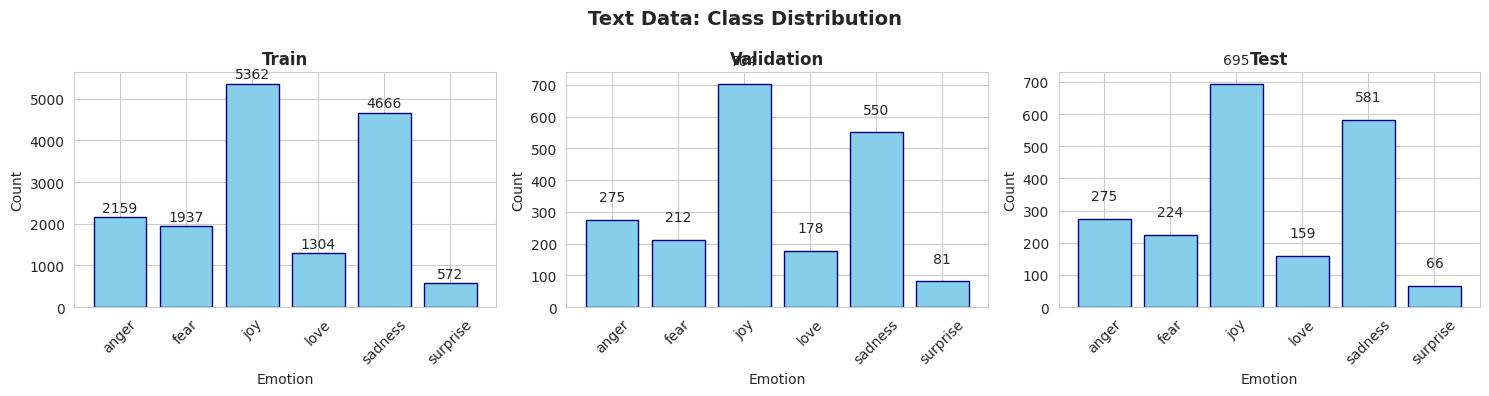


[6] Saving preprocessed text data...
   ✅ Saved to: text_data_preprocessed.pkl

[7] Text statistics:
   Average words per text: 19.2
   Min words: 2
   Max words: 66
   Median words: 17.0

📊 TEXT DATA SUMMARY
   Total samples: 20000
   Train: 16000 (80.0%)
   Val:   2000 (10.0%)
   Test:  2000 (10.0%)
   Emotions: 6 classes
   Avg length: 19.2 words

CELL 4 COMPLETED - Ready for next cell!


In [7]:
# ========================================
# CELL 4: Load & Preprocess Text Data
# ========================================

print("=" * 60)
print("CELL 4: TEXT DATA LOADING & PREPROCESSING")
print("=" * 60)

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

DATA_PATH = CONFIG['data_path']

# ==================== HELPER FUNCTIONS ====================
def load_text_data(file_path):
    """Load text data from semicolon-delimited file"""
    texts = []
    labels = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ';' in line:
                text, emotion = line.rsplit(';', 1)
                texts.append(text)
                labels.append(emotion)
    
    return texts, labels

def preprocess_text(text):
    """Clean and preprocess text"""
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# ==================== LOAD DATA ====================
print("\n[1] Loading text data files...")

train_texts, train_labels = load_text_data(f"{DATA_PATH}/train.txt")
val_texts, val_labels = load_text_data(f"{DATA_PATH}/val.txt")
test_texts, test_labels = load_text_data(f"{DATA_PATH}/test.txt")

print(f"   ✅ Train: {len(train_texts)} samples")
print(f"   ✅ Val:   {len(val_texts)} samples")
print(f"   ✅ Test:  {len(test_texts)} samples")
print(f"   ✅ Total: {len(train_texts) + len(val_texts) + len(test_texts)} samples")

# ==================== PREPROCESS ====================
print("\n[2] Preprocessing text data...")
print("   Cleaning: URLs, mentions, special chars, extra spaces...")

train_texts_clean = [preprocess_text(t) for t in train_texts]
val_texts_clean = [preprocess_text(t) for t in val_texts]
test_texts_clean = [preprocess_text(t) for t in test_texts]

print(f"   ✅ Preprocessing complete!")

# Show before/after examples
print("\n   [EXAMPLES] Before vs After:")
for i in range(3):
    print(f"\n   {i+1}. Original: '{train_texts[i][:70]}...'")
    print(f"      Cleaned:  '{train_texts_clean[i][:70]}...'")
    print(f"      Emotion:  {train_labels[i]}")

# ==================== LABEL ENCODING ====================
print("\n[3] Encoding emotion labels...")

label_encoder = LabelEncoder()
label_encoder.fit(train_labels + val_labels + test_labels)

train_labels_enc = label_encoder.transform(train_labels)
val_labels_enc = label_encoder.transform(val_labels)
test_labels_enc = label_encoder.transform(test_labels)

print(f"   ✅ Label encoding complete!")
print(f"   Emotion classes: {list(label_encoder.classes_)}")
print(f"   Number of classes: {len(label_encoder.classes_)}")

# Class distribution
print("\n[4] Class distribution:")
train_dist = Counter(train_labels)
val_dist = Counter(val_labels)
test_dist = Counter(test_labels)

print(f"\n   {'Emotion':<12} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print(f"   {'-'*52}")
for emotion in label_encoder.classes_:
    train_count = train_dist.get(emotion, 0)
    val_count = val_dist.get(emotion, 0)
    test_count = test_dist.get(emotion, 0)
    total = train_count + val_count + test_count
    print(f"   {emotion:<12} {train_count:<8} {val_count:<8} {test_count:<8} {total:<8}")

# Visualize distribution
print("\n[5] Visualizing class distribution...")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Text Data: Class Distribution', fontsize=14, fontweight='bold')

for idx, (dist, title) in enumerate([(train_dist, 'Train'), 
                                      (val_dist, 'Validation'), 
                                      (test_dist, 'Test')]):
    emotions = list(label_encoder.classes_)
    counts = [dist.get(e, 0) for e in emotions]
    
    axes[idx].bar(emotions, counts, color='skyblue', edgecolor='navy')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel('Emotion')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for i, count in enumerate(counts):
        axes[idx].text(i, count + 50, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('results/graphs/text_class_distribution.png', dpi=150, bbox_inches='tight')
print(f"   ✅ Graph saved: results/graphs/text_class_distribution.png")
plt.show()

# ==================== SAVE PREPROCESSED DATA ====================
print("\n[6] Saving preprocessed text data...")

text_data = {
    'train_texts': train_texts_clean,
    'train_labels': train_labels,
    'train_labels_enc': train_labels_enc,
    'val_texts': val_texts_clean,
    'val_labels': val_labels,
    'val_labels_enc': val_labels_enc,
    'test_texts': test_texts_clean,
    'test_labels': test_labels,
    'test_labels_enc': test_labels_enc,
    'label_encoder': label_encoder
}

with open('text_data_preprocessed.pkl', 'wb') as f:
    pickle.dump(text_data, f)

print(f"   ✅ Saved to: text_data_preprocessed.pkl")

# ==================== STATISTICS ====================
print("\n[7] Text statistics:")
train_lengths = [len(t.split()) for t in train_texts_clean]
print(f"   Average words per text: {np.mean(train_lengths):.1f}")
print(f"   Min words: {np.min(train_lengths)}")
print(f"   Max words: {np.max(train_lengths)}")
print(f"   Median words: {np.median(train_lengths):.1f}")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("📊 TEXT DATA SUMMARY")
print("=" * 60)
print(f"   Total samples: {len(train_texts) + len(val_texts) + len(test_texts)}")
print(f"   Train: {len(train_texts)} ({len(train_texts)/(len(train_texts)+len(val_texts)+len(test_texts))*100:.1f}%)")
print(f"   Val:   {len(val_texts)} ({len(val_texts)/(len(train_texts)+len(val_texts)+len(test_texts))*100:.1f}%)")
print(f"   Test:  {len(test_texts)} ({len(test_texts)/(len(train_texts)+len(val_texts)+len(test_texts))*100:.1f}%)")
print(f"   Emotions: {len(label_encoder.classes_)} classes")
print(f"   Avg length: {np.mean(train_lengths):.1f} words")

print("\n" + "=" * 60)
print("CELL 4 COMPLETED - Ready for next cell!")
print("=" * 60)

In [8]:
# ========================================
# CELL 5: TF-IDF Vectorization
# ========================================

print("=" * 60)
print("CELL 5: TF-IDF VECTORIZATION FOR ML MODELS")
print("=" * 60)

# Load preprocessed data
print("\n[1] Loading preprocessed text data...")
with open('text_data_preprocessed.pkl', 'rb') as f:
    text_data = pickle.load(f)

train_texts = text_data['train_texts']
train_labels_enc = text_data['train_labels_enc']
val_texts = text_data['val_texts']
val_labels_enc = text_data['val_labels_enc']
test_texts = text_data['test_texts']
test_labels_enc = text_data['test_labels_enc']
label_encoder = text_data['label_encoder']

print(f"   ✅ Loaded {len(train_texts)} train samples")
print(f"   ✅ Loaded {len(val_texts)} val samples")
print(f"   ✅ Loaded {len(test_texts)} test samples")

# ==================== TF-IDF VECTORIZATION ====================
print("\n[2] Creating TF-IDF vectorizer...")
print("   Parameters:")
print("      - max_features: 5000")
print("      - ngram_range: (1, 2)  # unigrams + bigrams")
print("      - min_df: 2  # word must appear in at least 2 documents")
print("      - max_df: 0.8  # word must appear in less than 80% of documents")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

print("\n[3] Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
print(f"   ✅ Training matrix shape: {X_train_tfidf.shape}")
print(f"      {X_train_tfidf.shape[0]} samples × {X_train_tfidf.shape[1]} features")

print("\n[4] Transforming validation and test data...")
X_val_tfidf = tfidf_vectorizer.transform(val_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)
print(f"   ✅ Validation matrix shape: {X_val_tfidf.shape}")
print(f"   ✅ Test matrix shape: {X_test_tfidf.shape}")

# ==================== VOCABULARY STATS ====================
print("\n[5] TF-IDF vocabulary statistics:")
vocab = tfidf_vectorizer.vocabulary_
print(f"   Total vocabulary size: {len(vocab)}")
print(f"   Features used: {X_train_tfidf.shape[1]}")

# Top features by average TF-IDF score
print("\n   [TOP 20 FEATURES] by avg TF-IDF score:")
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_indices = avg_tfidf.argsort()[-20:][::-1]

for i, idx in enumerate(top_indices, 1):
    print(f"      {i:2d}. {feature_names[idx]:<20s} (score: {avg_tfidf[idx]:.4f})")

# ==================== SPARSITY ====================
print("\n[6] Matrix sparsity:")
train_sparsity = 1.0 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
val_sparsity = 1.0 - (X_val_tfidf.nnz / (X_val_tfidf.shape[0] * X_val_tfidf.shape[1]))
test_sparsity = 1.0 - (X_test_tfidf.nnz / (X_test_tfidf.shape[0] * X_test_tfidf.shape[1]))

print(f"   Train sparsity: {train_sparsity*100:.2f}% (sparse)")
print(f"   Val sparsity:   {val_sparsity*100:.2f}%")
print(f"   Test sparsity:  {test_sparsity*100:.2f}%")
print(f"   💡 High sparsity = most values are zero (typical for text)")

# ==================== SAVE TF-IDF DATA ====================
print("\n[7] Saving TF-IDF vectorized data...")

tfidf_data = {
    'X_train_tfidf': X_train_tfidf,
    'X_val_tfidf': X_val_tfidf,
    'X_test_tfidf': X_test_tfidf,
    'y_train': train_labels_enc,
    'y_val': val_labels_enc,
    'y_test': test_labels_enc,
    'tfidf_vectorizer': tfidf_vectorizer,
    'label_encoder': label_encoder
}

with open('text_tfidf_data.pkl', 'wb') as f:
    pickle.dump(tfidf_data, f)

print(f"   ✅ Saved to: text_tfidf_data.pkl")

# ==================== VISUALIZE SAMPLE ====================
print("\n[8] Example: Text to TF-IDF conversion")
sample_idx = 0
sample_text = train_texts[sample_idx]
sample_emotion = label_encoder.classes_[train_labels_enc[sample_idx]]

print(f"\n   Original text: '{sample_text[:80]}...'")
print(f"   Emotion: {sample_emotion}")
print(f"   After TF-IDF: Vector of {X_train_tfidf.shape[1]} dimensions")

# Get non-zero features for this sample
sample_vector = X_train_tfidf[sample_idx]
nonzero_indices = sample_vector.nonzero()[1]
print(f"   Non-zero features: {len(nonzero_indices)} out of {X_train_tfidf.shape[1]}")

# Show top 10 features for this sample
print(f"\n   [TOP 10 FEATURES] for this sample:")
sample_scores = sample_vector.toarray().ravel()
top_sample_indices = sample_scores.argsort()[-10:][::-1]
for i, idx in enumerate(top_sample_indices, 1):
    if sample_scores[idx] > 0:
        print(f"      {i:2d}. {feature_names[idx]:<20s} (TF-IDF: {sample_scores[idx]:.4f})")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("📊 TF-IDF SUMMARY")
print("=" * 60)
print(f"   Vectorizer: TfidfVectorizer")
print(f"   Max features: 5000")
print(f"   N-grams: unigrams + bigrams")
print(f"   Vocabulary size: {len(vocab)}")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Val shape: {X_val_tfidf.shape}")
print(f"   Test shape: {X_test_tfidf.shape}")
print(f"   Sparsity: ~{train_sparsity*100:.1f}%")
print(f"\n   ✅ Ready for traditional ML training!")

print("\n" + "=" * 60)
print("CELL 5 COMPLETED - Ready for next cell!")
print("=" * 60)

CELL 5: TF-IDF VECTORIZATION FOR ML MODELS

[1] Loading preprocessed text data...
   ✅ Loaded 16000 train samples
   ✅ Loaded 2000 val samples
   ✅ Loaded 2000 test samples

[2] Creating TF-IDF vectorizer...
   Parameters:
      - max_features: 5000
      - ngram_range: (1, 2)  # unigrams + bigrams
      - min_df: 2  # word must appear in at least 2 documents
      - max_df: 0.8  # word must appear in less than 80% of documents

[3] Fitting TF-IDF on training data...
   ✅ Training matrix shape: (16000, 5000)
      16000 samples × 5000 features

[4] Transforming validation and test data...
   ✅ Validation matrix shape: (2000, 5000)
   ✅ Test matrix shape: (2000, 5000)

[5] TF-IDF vocabulary statistics:
   Total vocabulary size: 5000
   Features used: 5000

   [TOP 20 FEATURES] by avg TF-IDF score:
       1. feel                 (score: 0.0588)
       2. feeling              (score: 0.0397)
       3. like                 (score: 0.0271)
       4. im                   (score: 0.0246)
    

In [9]:
# ========================================
# CELL 6: Train All Text ML Models
# ========================================

print("=" * 60)
print("CELL 6: TRAINING TEXT TRADITIONAL ML MODELS")
print("=" * 60)

# Load TF-IDF data
print("\n[1] Loading TF-IDF data...")
with open('text_tfidf_data.pkl', 'rb') as f:
    tfidf_data = pickle.load(f)

X_train = tfidf_data['X_train_tfidf']
X_val = tfidf_data['X_val_tfidf']
X_test = tfidf_data['X_test_tfidf']
y_train = tfidf_data['y_train']
y_val = tfidf_data['y_val']
y_test = tfidf_data['y_test']
label_encoder = tfidf_data['label_encoder']

print(f"   ✅ X_train: {X_train.shape}")
print(f"   ✅ X_val: {X_val.shape}")
print(f"   ✅ X_test: {X_test.shape}")

# Store results
results = {}

# ==================== MODEL 1: SVM ====================
print("\n" + "=" * 60)
print("MODEL 1/5: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

print("\n[Training SVM...]")
print("   Parameters: kernel='linear', C=1.0, probability=True")
start_time = time.time()

svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Val Accuracy:  {val_acc*100:.2f}%")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

# Save model
joblib.dump(svm_model, 'results/models/text/text_svm.pkl')
print(f"   ✅ Model saved: results/models/text/text_svm.pkl")

results['SVM'] = {
    'val_acc': val_acc, 'test_acc': test_acc, 
    'precision': test_prec, 'recall': test_rec, 'f1': test_f1,
    'train_time': train_time
}

# ==================== MODEL 2: XGBoost ====================
print("\n" + "=" * 60)
print("MODEL 2/5: XGBOOST")
print("=" * 60)

print("\n[Training XGBoost...]")
print("   Parameters: n_estimators=100, max_depth=6, learning_rate=0.1")
start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Val Accuracy:  {val_acc*100:.2f}%")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump(xgb_model, 'results/models/text/text_xgboost.pkl')
print(f"   ✅ Model saved: results/models/text/text_xgboost.pkl")

results['XGBoost'] = {
    'val_acc': val_acc, 'test_acc': test_acc, 
    'precision': test_prec, 'recall': test_rec, 'f1': test_f1,
    'train_time': train_time
}

# ==================== MODEL 3: Random Forest ====================
print("\n" + "=" * 60)
print("MODEL 3/5: RANDOM FOREST")
print("=" * 60)

print("\n[Training Random Forest...]")
print("   Parameters: n_estimators=100, max_depth=20")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Val Accuracy:  {val_acc*100:.2f}%")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump(rf_model, 'results/models/text/text_rf.pkl')
print(f"   ✅ Model saved: results/models/text/text_rf.pkl")

results['RandomForest'] = {
    'val_acc': val_acc, 'test_acc': test_acc, 
    'precision': test_prec, 'recall': test_rec, 'f1': test_f1,
    'train_time': train_time
}

# ==================== MODEL 4: Naive Bayes ====================
print("\n" + "=" * 60)
print("MODEL 4/5: NAIVE BAYES")
print("=" * 60)

print("\n[Training Naive Bayes...]")
print("   Type: MultinomialNB (for TF-IDF)")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_val_pred = nb_model.predict(X_val)
y_test_pred = nb_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Val Accuracy:  {val_acc*100:.2f}%")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump(nb_model, 'results/models/text/text_nb.pkl')
print(f"   ✅ Model saved: results/models/text/text_nb.pkl")

results['NaiveBayes'] = {
    'val_acc': val_acc, 'test_acc': test_acc, 
    'precision': test_prec, 'recall': test_rec, 'f1': test_f1,
    'train_time': train_time
}

# ==================== MODEL 5: KNN ====================
print("\n" + "=" * 60)
print("MODEL 5/5: K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

print("\n[Training KNN...]")
print("   Parameters: n_neighbors=5, metric='cosine'")
start_time = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
knn_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_val_pred = knn_model.predict(X_val)
y_test_pred = knn_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Val Accuracy:  {val_acc*100:.2f}%")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump(knn_model, 'results/models/text/text_knn.pkl')
print(f"   ✅ Model saved: results/models/text/text_knn.pkl")

results['KNN'] = {
    'val_acc': val_acc, 'test_acc': test_acc, 
    'precision': test_prec, 'recall': test_rec, 'f1': test_f1,
    'train_time': train_time
}

# ==================== COMPARISON ====================
print("\n" + "=" * 60)
print("📊 TEXT ML MODELS COMPARISON")
print("=" * 60)

print(f"\n{'Model':<15} {'Val Acc':<10} {'Test Acc':<10} {'Precision':<11} {'Recall':<9} {'F1-Score':<10} {'Time (s)'}")
print("=" * 90)
for model_name, metrics in results.items():
    print(f"{model_name:<15} {metrics['val_acc']*100:>8.2f}% {metrics['test_acc']*100:>9.2f}% "
          f"{metrics['precision']:>10.4f} {metrics['recall']:>8.4f} {metrics['f1']:>9.4f} {metrics['train_time']:>9.2f}")

# Save results
with open('results/metrics/text_ml_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print(f"\n✅ Results saved: results/metrics/text_ml_results.json")

print("\n" + "=" * 60)
print("CELL 6 COMPLETED - 5 Text ML Models Trained!")
print("=" * 60)

CELL 6: TRAINING TEXT TRADITIONAL ML MODELS

[1] Loading TF-IDF data...
   ✅ X_train: (16000, 5000)
   ✅ X_val: (2000, 5000)
   ✅ X_test: (2000, 5000)

MODEL 1/5: SUPPORT VECTOR MACHINE (SVM)

[Training SVM...]
   Parameters: kernel='linear', C=1.0, probability=True
   ✅ Training completed in 77.66 seconds

   📊 Results:
      Val Accuracy:  90.30%
      Test Accuracy: 89.55%
      Precision:     0.8941
      Recall:        0.8955
      F1-Score:      0.8942
   ✅ Model saved: results/models/text/text_svm.pkl

MODEL 2/5: XGBOOST

[Training XGBoost...]
   Parameters: n_estimators=100, max_depth=6, learning_rate=0.1
   ✅ Training completed in 7.73 seconds

   📊 Results:
      Val Accuracy:  86.25%
      Test Accuracy: 85.50%
      Precision:     0.8653
      Recall:        0.8550
      F1-Score:      0.8561
   ✅ Model saved: results/models/text/text_xgboost.pkl

MODEL 3/5: RANDOM FOREST

[Training Random Forest...]
   Parameters: n_estimators=100, max_depth=20
   ✅ Training completed in 0

In [10]:
# ========================================
# CELL 7: Tokenization for DL Models
# ========================================

print("=" * 60)
print("CELL 7: TEXT TOKENIZATION FOR DEEP LEARNING")
print("=" * 60)

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

# Load preprocessed text
print("\n[1] Loading preprocessed text data...")
with open('text_data_preprocessed.pkl', 'rb') as f:
    text_data = pickle.load(f)

train_texts = text_data['train_texts']
train_labels_enc = text_data['train_labels_enc']
val_texts = text_data['val_texts']
val_labels_enc = text_data['val_labels_enc']
test_texts = text_data['test_texts']
test_labels_enc = text_data['test_labels_enc']
label_encoder = text_data['label_encoder']

print(f"   ✅ Train: {len(train_texts)} samples")
print(f"   ✅ Val: {len(val_texts)} samples")
print(f"   ✅ Test: {len(test_texts)} samples")

# ==================== BUILD VOCABULARY ====================
print("\n[2] Building vocabulary...")
print(f"   Max vocab size: {CONFIG['text_vocab_size']}")

# Count word frequencies
word_freq = Counter()
for text in train_texts:
    word_freq.update(text.split())

print(f"   Total unique words in training: {len(word_freq)}")

# Get most common words
most_common = word_freq.most_common(CONFIG['text_vocab_size'] - 2)  # -2 for PAD and UNK

# Create word-to-index mapping
word2idx = {'<PAD>': 0, '<UNK>': 1}
for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

vocab_size = len(word2idx)
print(f"   Vocabulary size: {vocab_size}")
print(f"   Top 20 words: {[w for w, _ in most_common[:20]]}")

# ==================== TOKENIZE ====================
print("\n[3] Tokenizing texts...")

def tokenize_text(text, word2idx, max_len):
    """Convert text to sequence of indices"""
    tokens = text.split()
    indices = [word2idx.get(word, word2idx['<UNK>']) for word in tokens]
    
    # Pad or truncate
    if len(indices) < max_len:
        indices += [word2idx['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    
    return indices

max_len = CONFIG['text_max_len']
print(f"   Max sequence length: {max_len}")

train_sequences = [tokenize_text(text, word2idx, max_len) for text in train_texts]
val_sequences = [tokenize_text(text, word2idx, max_len) for text in val_texts]
test_sequences = [tokenize_text(text, word2idx, max_len) for text in test_texts]

print(f"   ✅ Train sequences: {len(train_sequences)}")
print(f"   ✅ Val sequences: {len(val_sequences)}")
print(f"   ✅ Test sequences: {len(test_sequences)}")

# ==================== CONVERT TO TENSORS ====================
print("\n[4] Converting to PyTorch tensors...")

X_train_seq = torch.LongTensor(train_sequences)
y_train_seq = torch.LongTensor(train_labels_enc)
X_val_seq = torch.LongTensor(val_sequences)
y_val_seq = torch.LongTensor(val_labels_enc)
X_test_seq = torch.LongTensor(test_sequences)
y_test_seq = torch.LongTensor(test_labels_enc)

print(f"   ✅ X_train shape: {X_train_seq.shape}")
print(f"   ✅ y_train shape: {y_train_seq.shape}")
print(f"   ✅ X_val shape: {X_val_seq.shape}")
print(f"   ✅ X_test shape: {X_test_seq.shape}")

# ==================== CREATE DATALOADERS ====================
print("\n[5] Creating PyTorch DataLoaders...")

train_dataset = TensorDataset(X_train_seq, y_train_seq)
val_dataset = TensorDataset(X_val_seq, y_val_seq)
test_dataset = TensorDataset(X_test_seq, y_test_seq)

batch_size = CONFIG['text_batch_size']

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"   ✅ Train batches: {len(train_loader)} (batch_size={batch_size})")
print(f"   ✅ Val batches: {len(val_loader)}")
print(f"   ✅ Test batches: {len(test_loader)}")

# ==================== EXAMPLE ====================
print("\n[6] Example tokenization:")
sample_idx = 0
sample_text = train_texts[sample_idx]
sample_seq = train_sequences[sample_idx]
sample_label = label_encoder.classes_[train_labels_enc[sample_idx]]

print(f"\n   Original: '{sample_text}'")
print(f"   Emotion: {sample_label}")
print(f"   Tokenized (first 20): {sample_seq[:20]}")

# Decode back
decoded = ' '.join([list(word2idx.keys())[list(word2idx.values()).index(idx)] 
                    for idx in sample_seq[:20] if idx != 0])
print(f"   Decoded: '{decoded}'")

# ==================== SAVE ====================
print("\n[7] Saving tokenized data...")

tokenized_data = {
    'X_train': X_train_seq,
    'y_train': y_train_seq,
    'X_val': X_val_seq,
    'y_val': y_val_seq,
    'X_test': X_test_seq,
    'y_test': y_test_seq,
    'word2idx': word2idx,
    'vocab_size': vocab_size,
    'max_len': max_len,
    'label_encoder': label_encoder,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader
}

with open('text_tokenized_data.pkl', 'wb') as f:
    pickle.dump(tokenized_data, f)

print(f"   ✅ Saved to: text_tokenized_data.pkl")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("📊 TOKENIZATION SUMMARY")
print("=" * 60)
print(f"   Vocabulary size: {vocab_size}")
print(f"   Max sequence length: {max_len}")
print(f"   Train samples: {len(train_sequences)}")
print(f"   Val samples: {len(val_sequences)}")
print(f"   Test samples: {len(test_sequences)}")
print(f"   Batch size: {batch_size}")
print(f"   Number of classes: {len(label_encoder.classes_)}")
print(f"\n   ✅ Ready for LSTM & CNN-1D training!")

print("\n" + "=" * 60)
print("CELL 7 COMPLETED - Ready for next cell!")
print("=" * 60)

CELL 7: TEXT TOKENIZATION FOR DEEP LEARNING

[1] Loading preprocessed text data...
   ✅ Train: 16000 samples
   ✅ Val: 2000 samples
   ✅ Test: 2000 samples

[2] Building vocabulary...
   Max vocab size: 10000
   Total unique words in training: 15209
   Vocabulary size: 10000
   Top 20 words: ['i', 'feel', 'and', 'to', 'the', 'a', 'feeling', 'that', 'of', 'my', 'in', 'it', 'like', 'so', 'for', 'im', 'me', 'but', 'was', 'have']

[3] Tokenizing texts...
   Max sequence length: 100
   ✅ Train sequences: 16000
   ✅ Val sequences: 2000
   ✅ Test sequences: 2000

[4] Converting to PyTorch tensors...
   ✅ X_train shape: torch.Size([16000, 100])
   ✅ y_train shape: torch.Size([16000])
   ✅ X_val shape: torch.Size([2000, 100])
   ✅ X_test shape: torch.Size([2000, 100])

[5] Creating PyTorch DataLoaders...
   ✅ Train batches: 250 (batch_size=64)
   ✅ Val batches: 32
   ✅ Test batches: 32

[6] Example tokenization:

   Original: 'i didnt feel humiliated'
   Emotion: sadness
   Tokenized (first 20)

CELL 8: TRAINING BIDIRECTIONAL LSTM MODEL

[1] Loading tokenized data...
   ✅ Vocab size: 10000
   ✅ Num classes: 6
   ✅ Train batches: 250
   ✅ Device: cuda:0

[2] Defining BiLSTM architecture...
   Architecture:
      Embedding: 10000 -> 128
      BiLSTM: 128 -> 128*2 (2 layers)
      FC1: 256 -> 128
      FC2: 128 -> 6

   Total parameters: 1,973,126
   Trainable parameters: 1,973,126

[3] Setting up training...
   Loss: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau (patience=3)
   Epochs: 50

[4] Training BiLSTM...
   Epoch   1/50 | Train Loss: 1.5292 | Train Acc:  36.23% | Val Loss: 1.2642 | Val Acc:  51.75%
   Epoch   5/50 | Train Loss: 0.2654 | Train Acc:  90.91% | Val Loss: 0.3175 | Val Acc:  89.15%
   Epoch  10/50 | Train Loss: 0.0973 | Train Acc:  96.27% | Val Loss: 0.3370 | Val Acc:  91.00%
   Epoch  15/50 | Train Loss: 0.0538 | Train Acc:  98.08% | Val Loss: 0.4282 | Val Acc:  90.25%
   >>> Learning rate reduced: 0.001 -> 0.0005
   Epoch  20

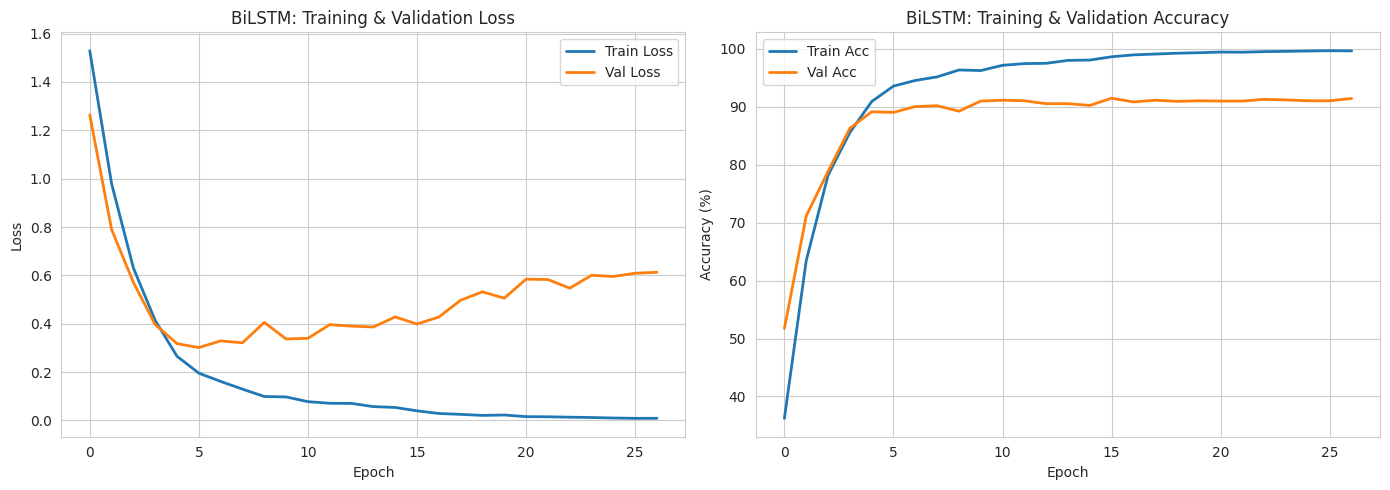


CELL 8 COMPLETED - BiLSTM Model Trained!


In [11]:
# ========================================
# CELL 8: Train BiLSTM Model (FIXED)
# ========================================

print("=" * 60)
print("CELL 8: TRAINING BIDIRECTIONAL LSTM MODEL")
print("=" * 60)

# Load tokenized data
print("\n[1] Loading tokenized data...")
with open('text_tokenized_data.pkl', 'rb') as f:
    tok_data = pickle.load(f)

train_loader = tok_data['train_loader']
val_loader = tok_data['val_loader']
test_loader = tok_data['test_loader']
vocab_size = tok_data['vocab_size']
label_encoder = tok_data['label_encoder']
num_classes = len(label_encoder.classes_)

print(f"   ✅ Vocab size: {vocab_size}")
print(f"   ✅ Num classes: {num_classes}")
print(f"   ✅ Train batches: {len(train_loader)}")

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

device = torch.device(CONFIG['device'])
print(f"   ✅ Device: {device}")

# ==================== DEFINE MODEL ====================
print("\n[2] Defining BiLSTM architecture...")

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.5):
        super(BiLSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, 
            hidden_dim, 
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 128)  # *2 for bidirectional
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)  # (batch, seq_len, hidden*2)
        
        # Take last hidden state from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)  # (batch, hidden*2)
        hidden = self.dropout(hidden)
        
        out = F.relu(self.fc1(hidden))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Initialize model
embed_dim = CONFIG['text_embed_dim']
hidden_dim = 128
num_layers = 2

model = BiLSTMModel(vocab_size, embed_dim, hidden_dim, num_classes, num_layers).to(device)

print(f"   Architecture:")
print(f"      Embedding: {vocab_size} -> {embed_dim}")
print(f"      BiLSTM: {embed_dim} -> {hidden_dim}*2 (2 layers)")
print(f"      FC1: {hidden_dim*2} -> 128")
print(f"      FC2: 128 -> {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ==================== TRAINING SETUP ====================
print("\n[3] Setting up training...")

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG['text_lr'])
# FIXED: Remove verbose parameter
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

epochs = CONFIG['text_epochs']
print(f"   Loss: CrossEntropyLoss")
print(f"   Optimizer: Adam (lr={CONFIG['text_lr']})")
print(f"   Scheduler: ReduceLROnPlateau (patience=3)")
print(f"   Epochs: {epochs}")

# ==================== TRAINING LOOP ====================
print("\n[4] Training BiLSTM...")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_epoch = 0

start_time = time.time()

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"   Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'results/models/text/text_lstm_best.pth')
    
    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"   >>> Learning rate reduced: {old_lr} -> {new_lr}")
    
    # Early stopping
    if epoch - best_epoch >= 10:
        print(f"\n   Early stopping at epoch {epoch+1} (no improvement for 10 epochs)")
        break

train_time = time.time() - start_time

print("=" * 60)
print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# ==================== TEST EVALUATION ====================
print("\n[5] Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load('results/models/text/text_lstm_best.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = output.max(1)
        
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec = recall_score(all_targets, all_preds, average='weighted')
test_f1 = f1_score(all_targets, all_preds, average='weighted')

print(f"\n   📊 Test Results:")
print(f"      Accuracy:  {test_acc:.2f}%")
print(f"      Precision: {test_prec:.4f}")
print(f"      Recall:    {test_rec:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# ==================== SAVE MODEL ====================
print("\n[6] Saving model...")

# Save full model
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'embed_dim': embed_dim,
    'hidden_dim': hidden_dim,
    'num_classes': num_classes,
    'num_layers': num_layers
}, 'results/models/text/text_lstm.pth')

print(f"   ✅ Model saved: results/models/text/text_lstm.pth")

# ==================== PLOT TRAINING CURVES ====================
print("\n[7] Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('BiLSTM: Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('BiLSTM: Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/graphs/training_curves/text_lstm_curves.png', dpi=150)
print(f"   ✅ Graph saved: results/graphs/training_curves/text_lstm_curves.png")
plt.show()

# ==================== SAVE RESULTS ====================
lstm_results = {
    'test_acc': test_acc / 100,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'train_time': train_time,
    'best_epoch': best_epoch,
    'total_params': total_params
}

with open('results/metrics/text_lstm_results.json', 'w') as f:
    json.dump(lstm_results, f, indent=4)

print("\n" + "=" * 60)
print("CELL 8 COMPLETED - BiLSTM Model Trained!")
print("=" * 60)

CELL 9: TRAINING CNN-1D MODEL

[1] Loading tokenized data...
   ✅ Vocab size: 10000
   ✅ Num classes: 6
   ✅ Device: cuda:0

[2] Defining CNN-1D architecture...
   Architecture:
      Embedding: 10000 -> 128
      Conv1D (kernel=3): 128 -> 128
      Conv1D (kernel=4): 128 -> 128
      Conv1D (kernel=5): 128 -> 128
      Concatenate: 128*3 = 384
      FC1: 384 -> 128
      FC2: 128 -> 6

   Total parameters: 1,527,046
   Trainable parameters: 1,527,046

[3] Setting up training...
   Loss: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau (patience=3)
   Epochs: 50

[4] Training CNN-1D...
   Epoch   1/50 | Train Loss: 1.5993 | Train Acc:  33.38% | Val Loss: 1.5578 | Val Acc:  37.65%
   Epoch   5/50 | Train Loss: 0.5023 | Train Acc:  82.21% | Val Loss: 0.3613 | Val Acc:  88.20%
   Epoch  10/50 | Train Loss: 0.1468 | Train Acc:  95.12% | Val Loss: 0.2783 | Val Acc:  91.70%
   Epoch  15/50 | Train Loss: 0.0849 | Train Acc:  97.05% | Val Loss: 0.3285 | Val Acc:  

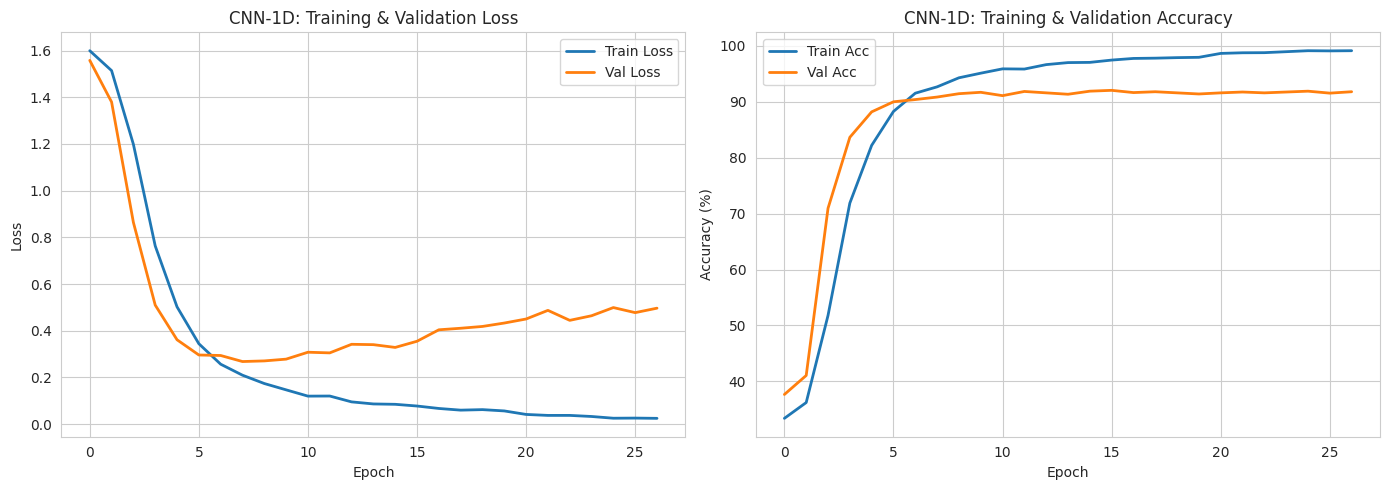


CELL 9 COMPLETED - CNN-1D Model Trained!


In [12]:
# ========================================
# CELL 9: Train CNN-1D Model
# ========================================

print("=" * 60)
print("CELL 9: TRAINING CNN-1D MODEL")
print("=" * 60)

# Load tokenized data
print("\n[1] Loading tokenized data...")
with open('text_tokenized_data.pkl', 'rb') as f:
    tok_data = pickle.load(f)

train_loader = tok_data['train_loader']
val_loader = tok_data['val_loader']
test_loader = tok_data['test_loader']
vocab_size = tok_data['vocab_size']
label_encoder = tok_data['label_encoder']
num_classes = len(label_encoder.classes_)

print(f"   ✅ Vocab size: {vocab_size}")
print(f"   ✅ Num classes: {num_classes}")

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

device = torch.device(CONFIG['device'])
print(f"   ✅ Device: {device}")

# ==================== DEFINE MODEL ====================
print("\n[2] Defining CNN-1D architecture...")

class CNN1DModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, dropout=0.5):
        super(CNN1DModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Multiple convolutional layers with different kernel sizes
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(embed_dim, 128, kernel_size=4, padding=2)
        self.conv3 = nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2)
        
        self.pool = nn.AdaptiveMaxPool1d(1)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(128 * 3, 128)  # 3 conv outputs concatenated
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)  # (batch, embed_dim, seq_len) for Conv1d
        
        # Apply convolutions
        conv1_out = F.relu(self.conv1(embedded))  # (batch, 128, seq_len)
        conv2_out = F.relu(self.conv2(embedded))  # (batch, 128, seq_len)
        conv3_out = F.relu(self.conv3(embedded))  # (batch, 128, seq_len)
        
        # Max pooling
        pool1 = self.pool(conv1_out).squeeze(2)  # (batch, 128)
        pool2 = self.pool(conv2_out).squeeze(2)  # (batch, 128)
        pool3 = self.pool(conv3_out).squeeze(2)  # (batch, 128)
        
        # Concatenate
        pooled = torch.cat([pool1, pool2, pool3], dim=1)  # (batch, 384)
        pooled = self.dropout(pooled)
        
        # Fully connected layers
        out = F.relu(self.fc1(pooled))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Initialize model
embed_dim = CONFIG['text_embed_dim']
model = CNN1DModel(vocab_size, embed_dim, num_classes).to(device)

print(f"   Architecture:")
print(f"      Embedding: {vocab_size} -> {embed_dim}")
print(f"      Conv1D (kernel=3): {embed_dim} -> 128")
print(f"      Conv1D (kernel=4): {embed_dim} -> 128")
print(f"      Conv1D (kernel=5): {embed_dim} -> 128")
print(f"      Concatenate: 128*3 = 384")
print(f"      FC1: 384 -> 128")
print(f"      FC2: 128 -> {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ==================== TRAINING SETUP ====================
print("\n[3] Setting up training...")

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG['text_lr'])
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

epochs = CONFIG['text_epochs']
print(f"   Loss: CrossEntropyLoss")
print(f"   Optimizer: Adam (lr={CONFIG['text_lr']})")
print(f"   Scheduler: ReduceLROnPlateau (patience=3)")
print(f"   Epochs: {epochs}")

# ==================== TRAINING LOOP ====================
print("\n[4] Training CNN-1D...")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_epoch = 0

start_time = time.time()

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"   Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'results/models/text/text_cnn1d_best.pth')
    
    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"   >>> Learning rate reduced: {old_lr} -> {new_lr}")
    
    # Early stopping
    if epoch - best_epoch >= 10:
        print(f"\n   Early stopping at epoch {epoch+1} (no improvement for 10 epochs)")
        break

train_time = time.time() - start_time

print("=" * 60)
print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# ==================== TEST EVALUATION ====================
print("\n[5] Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load('results/models/text/text_cnn1d_best.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = output.max(1)
        
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec = recall_score(all_targets, all_preds, average='weighted')
test_f1 = f1_score(all_targets, all_preds, average='weighted')

print(f"\n   📊 Test Results:")
print(f"      Accuracy:  {test_acc:.2f}%")
print(f"      Precision: {test_prec:.4f}")
print(f"      Recall:    {test_rec:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# ==================== SAVE MODEL ====================
print("\n[6] Saving model...")

torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'embed_dim': embed_dim,
    'num_classes': num_classes
}, 'results/models/text/text_cnn1d.pth')

print(f"   ✅ Model saved: results/models/text/text_cnn1d.pth")

# ==================== PLOT TRAINING CURVES ====================
print("\n[7] Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CNN-1D: Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('CNN-1D: Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/graphs/training_curves/text_cnn1d_curves.png', dpi=150)
print(f"   ✅ Graph saved: results/graphs/training_curves/text_cnn1d_curves.png")
plt.show()

# ==================== SAVE RESULTS ====================
cnn1d_results = {
    'test_acc': test_acc / 100,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'train_time': train_time,
    'best_epoch': best_epoch,
    'total_params': total_params
}

with open('results/metrics/text_cnn1d_results.json', 'w') as f:
    json.dump(cnn1d_results, f, indent=4)

print("\n" + "=" * 60)
print("CELL 9 COMPLETED - CNN-1D Model Trained!")
print("=" * 60)

CELL 10: LOADING FACIAL IMAGE DATA

[1] Configuration:
   Data path: data/data
   Image size: 48x48
   Batch size: 64

[2] Setting up emotion labels...
   Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Number of classes: 7

[3] Counting images...

   Emotion      Train    Test     Total   
   ----------------------------------------
   angry        3995     958      4953    
   disgust      436      111      547     
   fear         4097     1024     5121    
   happy        7215     1774     8989    
   neutral      4965     1233     6198    
   sad          4830     1247     6077    
   surprise     3171     831      4002    
   ----------------------------------------
   TOTAL        28709    7178     35887   

[4] Setting up image transforms...
   ✅ Train transform: Resize, Grayscale, RandomRotation, RandomAffine, Flip
   ✅ Test transform: Resize, Grayscale only

[5] Creating custom dataset class...
   ✅ Custom dataset class created

[6] Loading da

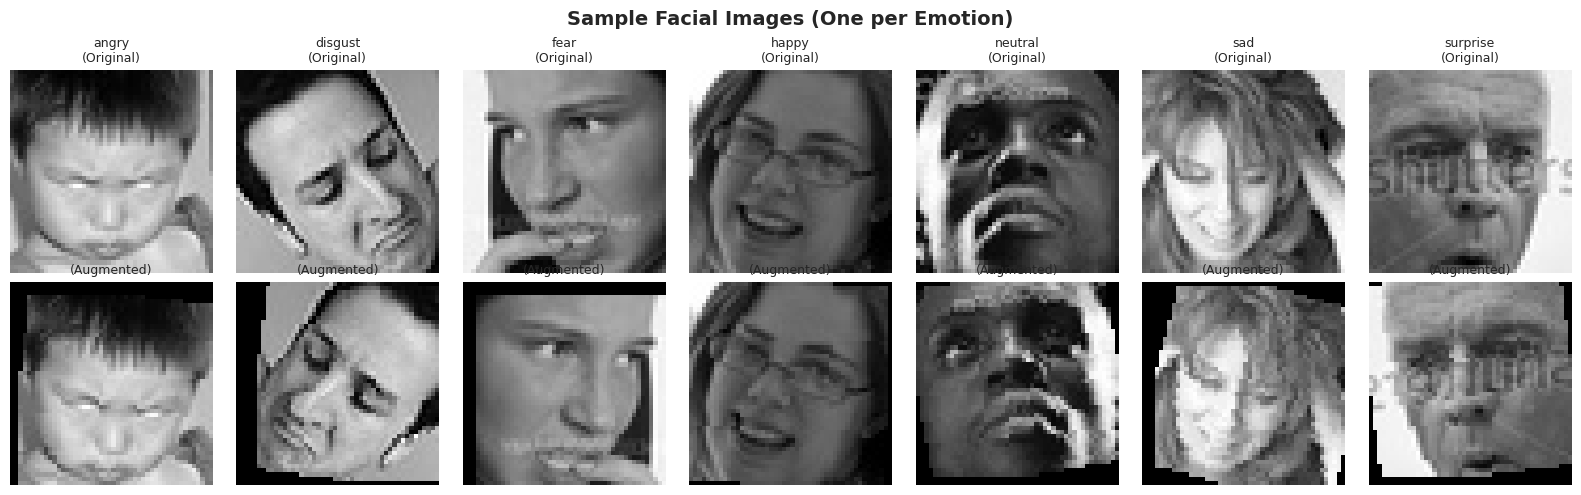


[9] Saving data loaders and mappings...
   ✅ Saved to: facial_data.pkl

📊 FACIAL DATA SUMMARY
   Train images: 25838
   Val images: 2871
   Test images: 7178
   Total: 35887
   Emotions: 7 classes
   Image size: 48x48 grayscale
   Batch size: 64

   ✅ Ready for facial model training!

CELL 10 COMPLETED - Ready for next cell!


In [13]:
# ========================================
# CELL 10: Load Facial Image Data
# ========================================

print("=" * 60)
print("CELL 10: LOADING FACIAL IMAGE DATA")
print("=" * 60)

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

DATA_PATH = CONFIG['data_path']
IMG_SIZE = CONFIG['img_size']
BATCH_SIZE = CONFIG['img_batch_size']

print(f"\n[1] Configuration:")
print(f"   Data path: {DATA_PATH}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")

# ==================== EMOTION MAPPING ====================
print("\n[2] Setting up emotion labels...")
facial_emotions = sorted(os.listdir(f"{DATA_PATH}/train"))
emotion2idx = {emotion: idx for idx, emotion in enumerate(facial_emotions)}
idx2emotion = {idx: emotion for emotion, idx in emotion2idx.items()}

print(f"   Emotions: {facial_emotions}")
print(f"   Number of classes: {len(facial_emotions)}")

# ==================== COUNT IMAGES ====================
print("\n[3] Counting images...")

train_counts = {}
test_counts = {}

for emotion in facial_emotions:
    train_path = f"{DATA_PATH}/train/{emotion}"
    test_path = f"{DATA_PATH}/test/{emotion}"
    
    train_imgs = [f for f in os.listdir(train_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    test_imgs = [f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    train_counts[emotion] = len(train_imgs)
    test_counts[emotion] = len(test_imgs)

print(f"\n   {'Emotion':<12} {'Train':<8} {'Test':<8} {'Total':<8}")
print(f"   {'-'*40}")
for emotion in facial_emotions:
    total = train_counts[emotion] + test_counts[emotion]
    print(f"   {emotion:<12} {train_counts[emotion]:<8} {test_counts[emotion]:<8} {total:<8}")

total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
print(f"   {'-'*40}")
print(f"   {'TOTAL':<12} {total_train:<8} {total_test:<8} {total_train + total_test:<8}")

# ==================== IMAGE TRANSFORMS ====================
print("\n[4] Setting up image transforms...")

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print(f"   ✅ Train transform: Resize, Grayscale, RandomRotation, RandomAffine, Flip")
print(f"   ✅ Test transform: Resize, Grayscale only")

# ==================== CUSTOM DATASET ====================
print("\n[5] Creating custom dataset class...")

from torch.utils.data import Dataset

class FacialEmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        # Load all image paths and labels
        for emotion in facial_emotions:
            emotion_dir = os.path.join(root_dir, emotion)
            label = emotion2idx[emotion]
            
            for img_name in os.listdir(emotion_dir):
                if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img_path = os.path.join(emotion_dir, img_name)
                    self.samples.append((img_path, label))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('L')  # Grayscale
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print(f"   ✅ Custom dataset class created")

# ==================== CREATE DATASETS ====================
print("\n[6] Loading datasets...")

train_dataset = FacialEmotionDataset(f"{DATA_PATH}/train", transform=train_transform)
test_dataset = FacialEmotionDataset(f"{DATA_PATH}/test", transform=test_transform)

# Split train into train/val (90/10)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"   ✅ Train dataset: {len(train_dataset)} images")
print(f"   ✅ Val dataset: {len(val_dataset)} images")
print(f"   ✅ Test dataset: {len(test_dataset)} images")

# ==================== CREATE DATALOADERS ====================
print("\n[7] Creating DataLoaders...")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"   ✅ Train batches: {len(train_loader)}")
print(f"   ✅ Val batches: {len(val_loader)}")
print(f"   ✅ Test batches: {len(test_loader)}")

# ==================== VISUALIZE SAMPLES ====================
print("\n[8] Visualizing sample images...")

fig, axes = plt.subplots(2, 7, figsize=(16, 5))
fig.suptitle('Sample Facial Images (One per Emotion)', fontsize=14, fontweight='bold')

for idx, emotion in enumerate(facial_emotions):
    emotion_dir = f"{DATA_PATH}/train/{emotion}"
    img_files = [f for f in os.listdir(emotion_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    # Load first image
    img_path = os.path.join(emotion_dir, img_files[0])
    img = Image.open(img_path).convert('L')
    
    # Original
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'{emotion}\n(Original)', fontsize=9)
    axes[0, idx].axis('off')
    
    # Augmented
    aug_img = train_transform(img)
    aug_img_display = aug_img.squeeze().numpy()
    axes[1, idx].imshow(aug_img_display, cmap='gray')
    axes[1, idx].set_title('(Augmented)', fontsize=9)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('results/graphs/facial_sample_images.png', dpi=150, bbox_inches='tight')
print(f"   ✅ Graph saved: results/graphs/facial_sample_images.png")
plt.show()

# ==================== SAVE DATA ====================
print("\n[9] Saving data loaders and mappings...")

facial_data = {
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader,
    'emotion2idx': emotion2idx,
    'idx2emotion': idx2emotion,
    'num_classes': len(facial_emotions),
    'img_size': IMG_SIZE
}

with open('facial_data.pkl', 'wb') as f:
    pickle.dump(facial_data, f)

print(f"   ✅ Saved to: facial_data.pkl")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("📊 FACIAL DATA SUMMARY")
print("=" * 60)
print(f"   Train images: {len(train_dataset)}")
print(f"   Val images: {len(val_dataset)}")
print(f"   Test images: {len(test_dataset)}")
print(f"   Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"   Emotions: {len(facial_emotions)} classes")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE} grayscale")
print(f"   Batch size: {BATCH_SIZE}")
print(f"\n   ✅ Ready for facial model training!")

print("\n" + "=" * 60)
print("CELL 10 COMPLETED - Ready for next cell!")
print("=" * 60)

CELL 11: TRAINING CUSTOM DEEP CNN MODEL

[1] Loading facial data...
   ✅ Train batches: 404
   ✅ Val batches: 45
   ✅ Test batches: 113
   ✅ Num classes: 7
   ✅ Device: cuda:0

[2] Defining Deep CNN architecture...
   Architecture:
      Block 1: 1 -> 64 -> 64 (MaxPool)
      Block 2: 64 -> 128 -> 128 (MaxPool)
      Block 3: 128 -> 256 -> 256 (MaxPool)
      Block 4: 256 -> 512 -> 512 (MaxPool)
      Global Avg Pool
      FC: 512 -> 256 -> 128 -> 7

   Total parameters: 4,853,959
   Trainable parameters: 4,853,959

[3] Setting up training...
   Loss: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau (patience=5)
   Epochs: 100

[4] Training Deep CNN...
   ⚠️  This will take 30-45 minutes on RTX 4090
   Epoch   1/100 | Train Loss: 1.8521 | Train Acc:  22.92% | Val Loss: 1.7840 | Val Acc:  25.53% | Time: 0.1m
   Epoch   5/100 | Train Loss: 1.7536 | Train Acc:  28.06% | Val Loss: 1.7141 | Val Acc:  30.37% | Time: 0.5m
   Epoch  10/100 | Train Loss: 1.4192 | T

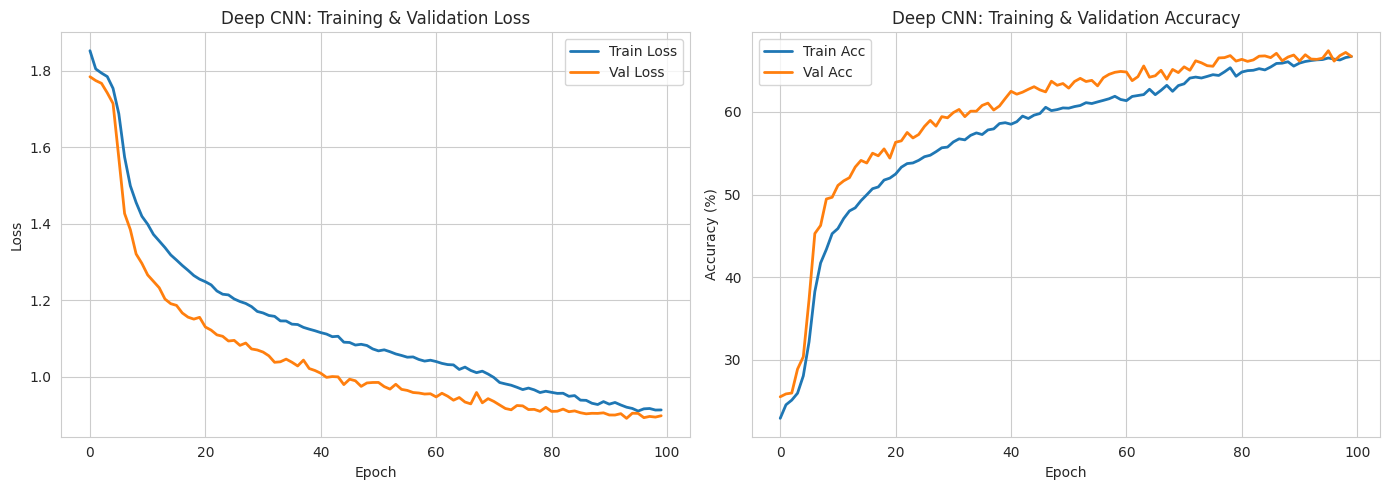


CELL 11 COMPLETED - Deep CNN Model Trained!


In [14]:
# ========================================
# CELL 11: Train Custom Deep CNN Model
# ========================================

print("=" * 60)
print("CELL 11: TRAINING CUSTOM DEEP CNN MODEL")
print("=" * 60)

# Load facial data
print("\n[1] Loading facial data...")
with open('facial_data.pkl', 'rb') as f:
    facial_data = pickle.load(f)

train_loader = facial_data['train_loader']
val_loader = facial_data['val_loader']
test_loader = facial_data['test_loader']
idx2emotion = facial_data['idx2emotion']
num_classes = facial_data['num_classes']

print(f"   ✅ Train batches: {len(train_loader)}")
print(f"   ✅ Val batches: {len(val_loader)}")
print(f"   ✅ Test batches: {len(test_loader)}")
print(f"   ✅ Num classes: {num_classes}")

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

device = torch.device(CONFIG['device'])
print(f"   ✅ Device: {device}")

# ==================== DEFINE DEEP CNN MODEL ====================
print("\n[2] Defining Deep CNN architecture...")

class DeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(DeepCNN, self).__init__()
        
        # Block 1
        self.conv1_1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.4)
        
        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.4)
        
        # Block 3
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.5)
        
        # Block 4
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout2d(0.5)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(512, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout_fc1 = nn.Dropout(0.6)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.dropout_fc2 = nn.Dropout(0.6)
        
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1: 48x48 -> 24x24
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2: 24x24 -> 12x12
        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3: 12x12 -> 6x6
        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Block 4: 6x6 -> 3x3
        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        
        # Global pooling: 3x3 -> 1x1
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        
        # FC layers
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc1(x)
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout_fc2(x)
        x = self.fc3(x)
        
        return x

# Initialize model
model = DeepCNN(num_classes=num_classes).to(device)

print(f"   Architecture:")
print(f"      Block 1: 1 -> 64 -> 64 (MaxPool)")
print(f"      Block 2: 64 -> 128 -> 128 (MaxPool)")
print(f"      Block 3: 128 -> 256 -> 256 (MaxPool)")
print(f"      Block 4: 256 -> 512 -> 512 (MaxPool)")
print(f"      Global Avg Pool")
print(f"      FC: 512 -> 256 -> 128 -> {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ==================== TRAINING SETUP ====================
print("\n[3] Setting up training...")

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG['img_lr'])
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = CONFIG['img_epochs']
print(f"   Loss: CrossEntropyLoss")
print(f"   Optimizer: Adam (lr={CONFIG['img_lr']})")
print(f"   Scheduler: ReduceLROnPlateau (patience=5)")
print(f"   Epochs: {epochs}")

# ==================== TRAINING LOOP ====================
print("\n[4] Training Deep CNN...")
print("=" * 60)
print("   ⚠️  This will take 30-45 minutes on RTX 4090")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_epoch = 0

start_time = time.time()

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"   Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}% | "
              f"Time: {elapsed/60:.1f}m")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'results/models/facial/facial_dcnn_best.pth')
    
    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"   >>> Learning rate reduced: {old_lr} -> {new_lr}")
    
    # Early stopping
    if epoch - best_epoch >= 15:
        print(f"\n   Early stopping at epoch {epoch+1} (no improvement for 15 epochs)")
        break

train_time = time.time() - start_time

print("=" * 60)
print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# ==================== TEST EVALUATION ====================
print("\n[5] Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load('results/models/facial/facial_dcnn_best.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = output.max(1)
        
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec = recall_score(all_targets, all_preds, average='weighted')
test_f1 = f1_score(all_targets, all_preds, average='weighted')

print(f"\n   📊 Test Results:")
print(f"      Accuracy:  {test_acc:.2f}%")
print(f"      Precision: {test_prec:.4f}")
print(f"      Recall:    {test_rec:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# ==================== SAVE MODEL ====================
print("\n[6] Saving model...")

torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes
}, 'results/models/facial/facial_dcnn.pth')

print(f"   ✅ Model saved: results/models/facial/facial_dcnn.pth")

# ==================== PLOT TRAINING CURVES ====================
print("\n[7] Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Deep CNN: Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Deep CNN: Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/graphs/training_curves/facial_dcnn_curves.png', dpi=150)
print(f"   ✅ Graph saved: results/graphs/training_curves/facial_dcnn_curves.png")
plt.show()

# ==================== SAVE RESULTS ====================
dcnn_results = {
    'test_acc': test_acc / 100,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'train_time': train_time,
    'best_epoch': best_epoch,
    'total_params': total_params
}

with open('results/metrics/facial_dcnn_results.json', 'w') as f:
    json.dump(dcnn_results, f, indent=4)

print("\n" + "=" * 60)
print("CELL 11 COMPLETED - Deep CNN Model Trained!")
print("=" * 60)

CELL 12: TRAINING MLP (MULTI-LAYER PERCEPTRON) MODEL

[1] Loading facial data...
   ✅ Train batches: 404
   ✅ Num classes: 7
   ✅ Device: cuda:0

[2] Defining MLP architecture...
   Architecture:
      Input: 2304 (flattened 48x48)
      FC1: 2304 -> 1024
      FC2: 1024 -> 512
      FC3: 512 -> 256
      FC4: 256 -> 128
      FC5: 128 -> 7

   Total parameters: 3,053,831
   Trainable parameters: 3,053,831

[3] Setting up training...
   Loss: CrossEntropyLoss
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau (patience=5)
   Epochs: 80

[4] Training MLP...
   Epoch   1/80 | Train Loss: 1.7966 | Train Acc:  25.44% | Val Loss: 1.7532 | Val Acc:  28.28%
   Epoch   5/80 | Train Loss: 1.7293 | Train Acc:  30.50% | Val Loss: 1.6951 | Val Acc:  33.23%
   Epoch  10/80 | Train Loss: 1.7025 | Train Acc:  32.58% | Val Loss: 1.6610 | Val Acc:  34.69%
   Epoch  15/80 | Train Loss: 1.6837 | Train Acc:  33.25% | Val Loss: 1.6402 | Val Acc:  35.53%
   Epoch  20/80 | Train Loss: 1.6683 | Tra

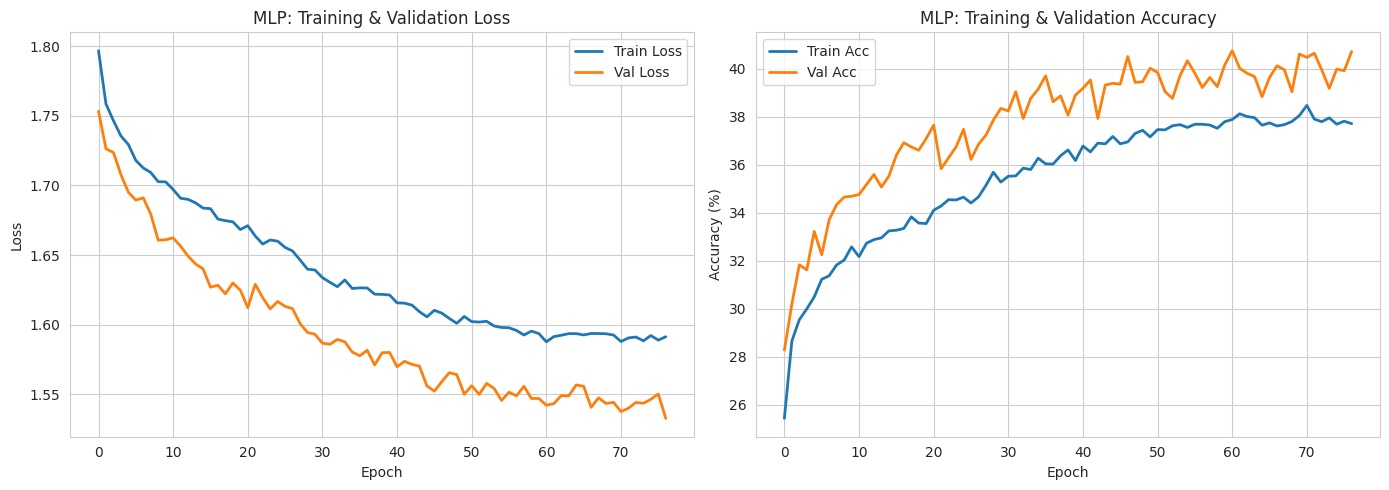


CELL 12 COMPLETED - MLP Model Trained!


In [15]:
# ========================================
# CELL 12: Train MLP Model
# ========================================

print("=" * 60)
print("CELL 12: TRAINING MLP (MULTI-LAYER PERCEPTRON) MODEL")
print("=" * 60)

# Load facial data
print("\n[1] Loading facial data...")
with open('facial_data.pkl', 'rb') as f:
    facial_data = pickle.load(f)

train_loader = facial_data['train_loader']
val_loader = facial_data['val_loader']
test_loader = facial_data['test_loader']
num_classes = facial_data['num_classes']
img_size = facial_data['img_size']

print(f"   ✅ Train batches: {len(train_loader)}")
print(f"   ✅ Num classes: {num_classes}")

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

device = torch.device(CONFIG['device'])
print(f"   ✅ Device: {device}")

# ==================== DEFINE MLP MODEL ====================
print("\n[2] Defining MLP architecture...")

class MLPModel(nn.Module):
    def __init__(self, input_size, num_classes=7, dropout=0.5):
        super(MLPModel, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(dropout)
        
        self.fc4 = nn.Linear(256, 128)
        self.dropout4 = nn.Dropout(0.4)
        
        self.fc5 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = F.relu(self.fc4(x))
        x = self.dropout4(x)
        
        x = self.fc5(x)
        return x

# Initialize model
input_size = img_size * img_size  # 48*48 = 2304
model = MLPModel(input_size, num_classes).to(device)

print(f"   Architecture:")
print(f"      Input: {input_size} (flattened {img_size}x{img_size})")
print(f"      FC1: {input_size} -> 1024")
print(f"      FC2: 1024 -> 512")
print(f"      FC3: 512 -> 256")
print(f"      FC4: 256 -> 128")
print(f"      FC5: 128 -> {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ==================== TRAINING SETUP ====================
print("\n[3] Setting up training...")

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG['img_lr'])
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 80  # Fewer epochs for MLP
print(f"   Loss: CrossEntropyLoss")
print(f"   Optimizer: Adam (lr={CONFIG['img_lr']})")
print(f"   Scheduler: ReduceLROnPlateau (patience=5)")
print(f"   Epochs: {epochs}")

# ==================== TRAINING LOOP ====================
print("\n[4] Training MLP...")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_epoch = 0

start_time = time.time()

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"   Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'results/models/facial/facial_mlp_best.pth')
    
    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"   >>> Learning rate reduced: {old_lr} -> {new_lr}")
    
    # Early stopping
    if epoch - best_epoch >= 15:
        print(f"\n   Early stopping at epoch {epoch+1} (no improvement for 15 epochs)")
        break

train_time = time.time() - start_time

print("=" * 60)
print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# ==================== TEST EVALUATION ====================
print("\n[5] Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load('results/models/facial/facial_mlp_best.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = output.max(1)
        
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec = recall_score(all_targets, all_preds, average='weighted')
test_f1 = f1_score(all_targets, all_preds, average='weighted')

print(f"\n   📊 Test Results:")
print(f"      Accuracy:  {test_acc:.2f}%")
print(f"      Precision: {test_prec:.4f}")
print(f"      Recall:    {test_rec:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# ==================== SAVE MODEL ====================
print("\n[6] Saving model...")

torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'num_classes': num_classes
}, 'results/models/facial/facial_mlp.pth')

print(f"   ✅ Model saved: results/models/facial/facial_mlp.pth")

# ==================== PLOT TRAINING CURVES ====================
print("\n[7] Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MLP: Training & Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MLP: Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/graphs/training_curves/facial_mlp_curves.png', dpi=150)
print(f"   ✅ Graph saved: results/graphs/training_curves/facial_mlp_curves.png")
plt.show()

# ==================== SAVE RESULTS ====================
mlp_results = {
    'test_acc': test_acc / 100,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'train_time': train_time,
    'best_epoch': best_epoch,
    'total_params': total_params
}

with open('results/metrics/facial_mlp_results.json', 'w') as f:
    json.dump(mlp_results, f, indent=4)

print("\n" + "=" * 60)
print("CELL 12 COMPLETED - MLP Model Trained!")
print("=" * 60)

In [16]:
# ========================================
# CELL 13: Train All Facial ML Models
# ========================================

print("=" * 60)
print("CELL 13: TRAINING FACIAL TRADITIONAL ML MODELS")
print("=" * 60)

# Load facial data
print("\n[1] Loading facial image data...")
with open('facial_data.pkl', 'rb') as f:
    facial_data = pickle.load(f)

train_loader = facial_data['train_loader']
test_loader = facial_data['test_loader']
emotion2idx = facial_data['emotion2idx']
idx2emotion = facial_data['idx2emotion']
num_classes = facial_data['num_classes']
img_size = facial_data['img_size']

print(f"   ✅ Train batches: {len(train_loader)}")
print(f"   ✅ Test batches: {len(test_loader)}")
print(f"   ✅ Image size: {img_size}x{img_size}")

# ==================== LOAD & FLATTEN IMAGES ====================
print("\n[2] Loading and flattening images...")
print("   This will take 2-3 minutes...")

X_train = []
y_train = []
X_test = []
y_test = []

# Load training data
for batch_idx, (data, target) in enumerate(train_loader):
    imgs = data.numpy()
    imgs = imgs.reshape(imgs.shape[0], -1)  # Flatten: (batch, 1, 48, 48) -> (batch, 2304)
    X_train.append(imgs)
    y_train.append(target.numpy())

# Load test data
for batch_idx, (data, target) in enumerate(test_loader):
    imgs = data.numpy()
    imgs = imgs.reshape(imgs.shape[0], -1)
    X_test.append(imgs)
    y_test.append(target.numpy())

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)
X_test = np.vstack(X_test)
y_test = np.concatenate(y_test)

print(f"   ✅ X_train shape: {X_train.shape}")
print(f"   ✅ X_test shape: {X_test.shape}")
print(f"   ✅ Feature dimension: {X_train.shape[1]}")

# ==================== APPLY PCA ====================
print("\n[3] Applying PCA for dimensionality reduction...")
print("   Reducing from 2304 to 200 features (for SVM/KNN speed)...")

pca = PCA(n_components=200, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance_explained = pca.explained_variance_ratio_.sum()
print(f"   ✅ PCA complete!")
print(f"   Variance explained: {variance_explained*100:.2f}%")
print(f"   X_train_pca shape: {X_train_pca.shape}")

# ==================== STANDARDIZE ====================
print("\n[4] Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)

print(f"   ✅ Standardization complete!")

# Store results
results = {}

# ==================== MODEL 1: SVM (with PCA) ====================
print("\n" + "=" * 60)
print("MODEL 1/5: SUPPORT VECTOR MACHINE (SVM) with PCA")
print("=" * 60)

print("\n[Training SVM...]")
print("   Parameters: kernel='rbf', C=1.0 (on PCA features)")
start_time = time.time()

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_pca_scaled, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_test_pred = svm_model.predict(X_test_pca_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

# Save
joblib.dump({'model': svm_model, 'pca': pca, 'scaler': scaler}, 
            'results/models/facial/facial_svm.pkl')
print(f"   ✅ Model saved: results/models/facial/facial_svm.pkl")

results['SVM'] = {
    'test_acc': test_acc, 'precision': test_prec, 
    'recall': test_rec, 'f1': test_f1, 'train_time': train_time
}

# ==================== MODEL 2: XGBoost ====================
print("\n" + "=" * 60)
print("MODEL 2/5: XGBOOST")
print("=" * 60)

print("\n[Training XGBoost...]")
print("   Parameters: n_estimators=100, max_depth=8")
start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=8, 
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_test_pred = xgb_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump({'model': xgb_model, 'scaler': scaler}, 
            'results/models/facial/facial_xgboost.pkl')
print(f"   ✅ Model saved: results/models/facial/facial_xgboost.pkl")

results['XGBoost'] = {
    'test_acc': test_acc, 'precision': test_prec, 
    'recall': test_rec, 'f1': test_f1, 'train_time': train_time
}

# ==================== MODEL 3: Random Forest ====================
print("\n" + "=" * 60)
print("MODEL 3/5: RANDOM FOREST")
print("=" * 60)

print("\n[Training Random Forest...]")
print("   Parameters: n_estimators=100, max_depth=25")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=25, 
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_test_pred = rf_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump({'model': rf_model, 'scaler': scaler}, 
            'results/models/facial/facial_rf.pkl')
print(f"   ✅ Model saved: results/models/facial/facial_rf.pkl")

results['RandomForest'] = {
    'test_acc': test_acc, 'precision': test_prec, 
    'recall': test_rec, 'f1': test_f1, 'train_time': train_time
}

# ==================== MODEL 4: KNN (with PCA) ====================
print("\n" + "=" * 60)
print("MODEL 4/5: K-NEAREST NEIGHBORS (KNN) with PCA")
print("=" * 60)

print("\n[Training KNN...]")
print("   Parameters: n_neighbors=7 (on PCA features)")
start_time = time.time()

knn_model = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn_model.fit(X_train_pca_scaled, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_test_pred = knn_model.predict(X_test_pca_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump({'model': knn_model, 'pca': pca, 'scaler': scaler}, 
            'results/models/facial/facial_knn.pkl')
print(f"   ✅ Model saved: results/models/facial/facial_knn.pkl")

results['KNN'] = {
    'test_acc': test_acc, 'precision': test_prec, 
    'recall': test_rec, 'f1': test_f1, 'train_time': train_time
}

# ==================== MODEL 5: Naive Bayes ====================
print("\n" + "=" * 60)
print("MODEL 5/5: NAIVE BAYES (Gaussian)")
print("=" * 60)

print("\n[Training Naive Bayes...]")
start_time = time.time()

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"   ✅ Training completed in {train_time:.2f} seconds")

# Evaluate
y_test_pred = nb_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n   📊 Results:")
print(f"      Test Accuracy: {test_acc*100:.2f}%")
print(f"      Precision:     {test_prec:.4f}")
print(f"      Recall:        {test_rec:.4f}")
print(f"      F1-Score:      {test_f1:.4f}")

joblib.dump({'model': nb_model, 'scaler': scaler}, 
            'results/models/facial/facial_nb.pkl')
print(f"   ✅ Model saved: results/models/facial/facial_nb.pkl")

results['NaiveBayes'] = {
    'test_acc': test_acc, 'precision': test_prec, 
    'recall': test_rec, 'f1': test_f1, 'train_time': train_time
}

# ==================== COMPARISON ====================
print("\n" + "=" * 60)
print("📊 FACIAL ML MODELS COMPARISON")
print("=" * 60)

print(f"\n{'Model':<15} {'Test Acc':<10} {'Precision':<11} {'Recall':<9} {'F1-Score':<10} {'Time (s)'}")
print("=" * 75)
for model_name, metrics in results.items():
    print(f"{model_name:<15} {metrics['test_acc']*100:>8.2f}% "
          f"{metrics['precision']:>10.4f} {metrics['recall']:>8.4f} "
          f"{metrics['f1']:>9.4f} {metrics['train_time']:>9.2f}")

# Save results
with open('results/metrics/facial_ml_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print(f"\n✅ Results saved: results/metrics/facial_ml_results.json")

print("\n" + "=" * 60)
print("CELL 13 COMPLETED - All Facial ML Models Trained!")
print("=" * 60)

CELL 13: TRAINING FACIAL TRADITIONAL ML MODELS

[1] Loading facial image data...
   ✅ Train batches: 404
   ✅ Test batches: 113
   ✅ Image size: 48x48

[2] Loading and flattening images...
   This will take 2-3 minutes...
   ✅ X_train shape: (25838, 2304)
   ✅ X_test shape: (7178, 2304)
   ✅ Feature dimension: 2304

[3] Applying PCA for dimensionality reduction...
   Reducing from 2304 to 200 features (for SVM/KNN speed)...
   ✅ PCA complete!
   Variance explained: 91.93%
   X_train_pca shape: (25838, 200)

[4] Standardizing features...
   ✅ Standardization complete!

MODEL 1/5: SUPPORT VECTOR MACHINE (SVM) with PCA

[Training SVM...]
   Parameters: kernel='rbf', C=1.0 (on PCA features)
   ✅ Training completed in 193.13 seconds

   📊 Results:
      Test Accuracy: 35.20%
      Precision:     0.3390
      Recall:        0.3520
      F1-Score:      0.2947
   ✅ Model saved: results/models/facial/facial_svm.pkl

MODEL 2/5: XGBOOST

[Training XGBoost...]
   Parameters: n_estimators=100, max_

CELL 14: FINAL EVALUATION & VISUALIZATION

[1] Loading all model results...
   ✅ All results loaded!

[2] Creating text models comparison chart...
   ✅ Saved: results/graphs/text_models_comparison.png


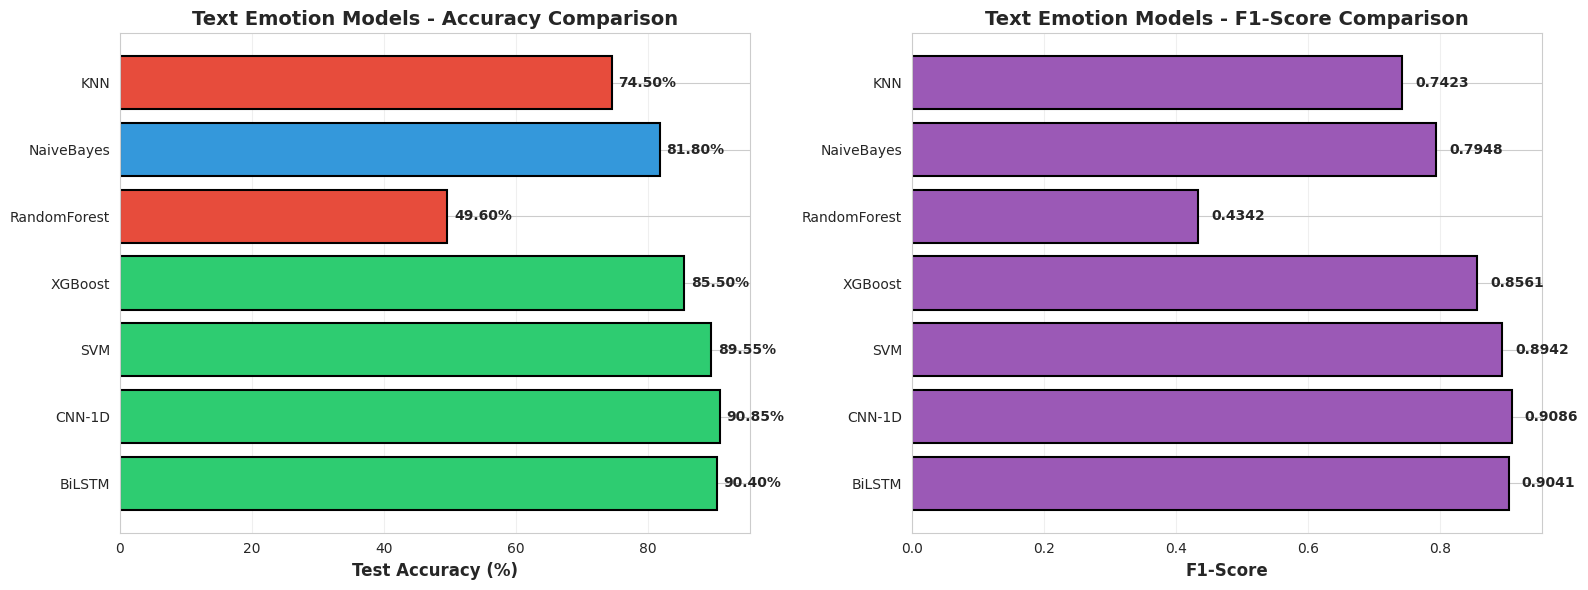


[3] Creating facial models comparison chart...
   ✅ Saved: results/graphs/facial_models_comparison.png


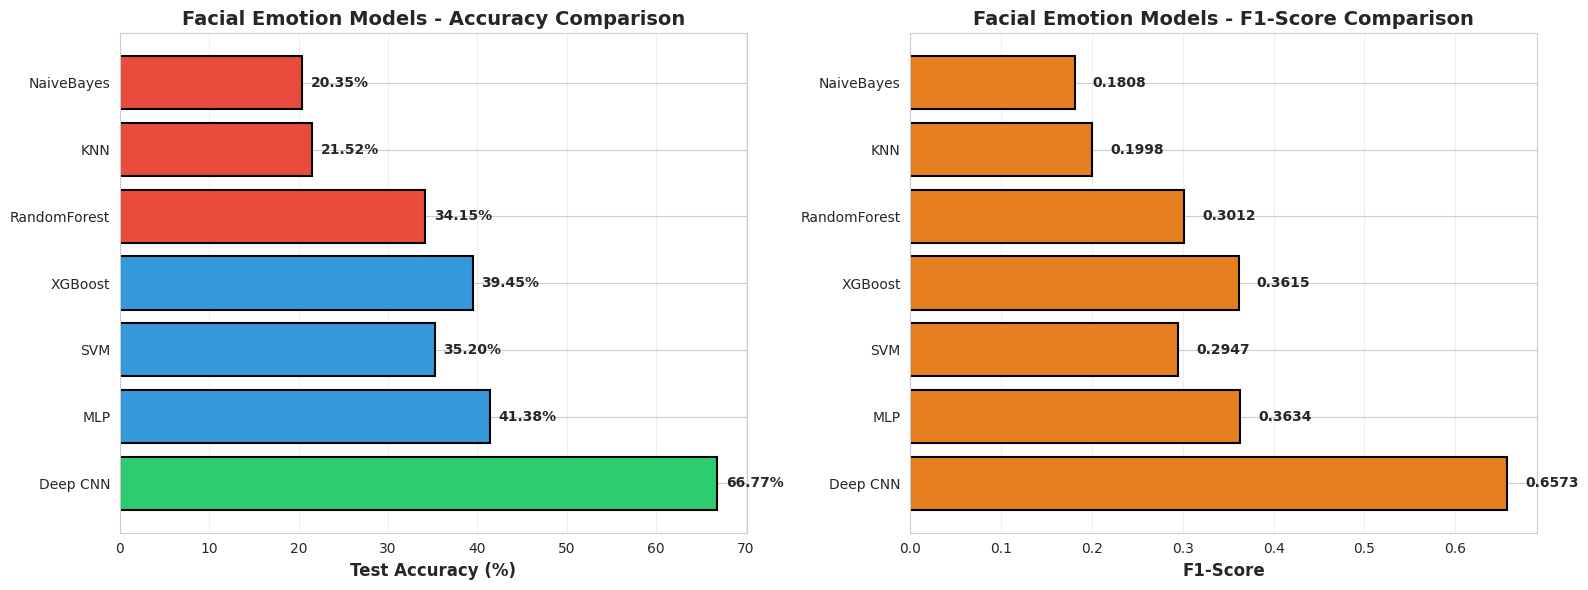


[4] Creating master comparison chart...
   ✅ Saved: results/graphs/master_comparison.png


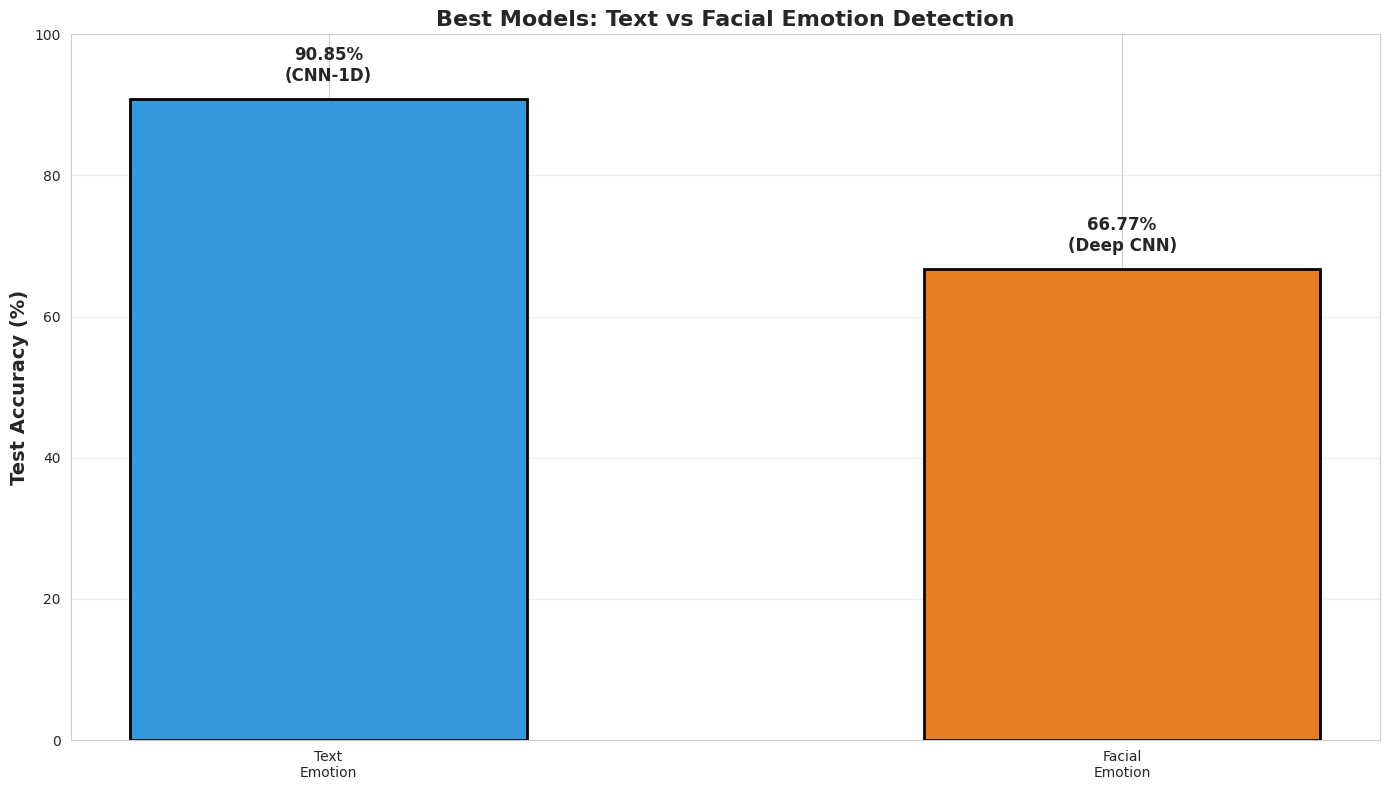


[5] Saving final results CSV...
   ✅ Saved: results/metrics/text_all_results.csv
   ✅ Saved: results/metrics/facial_all_results.csv
   ✅ Saved: results/metrics/all_models_results.csv

🎉 TRAINING COMPLETE! FINAL SUMMARY

📊 TEXT EMOTION DETECTION (6 classes):
   Best Model: CNN-1D
   Accuracy: 90.85%
   F1-Score: 0.9086

📊 FACIAL EMOTION RECOGNITION (7 classes):
   Best Model: Deep CNN
   Accuracy: 66.77%
   F1-Score: 0.6573

📁 All results saved in:
   • results/models/ (14 trained models)
   • results/metrics/ (JSON + CSV results)
   • results/graphs/ (comparison charts)

CELL 14 COMPLETED - ALL DONE! 🎉


In [17]:
# ========================================
# CELL 14: Final Evaluation & Visualization
# ========================================

print("=" * 60)
print("CELL 14: FINAL EVALUATION & VISUALIZATION")
print("=" * 60)

# Load all results
print("\n[1] Loading all model results...")

# Text results
with open('results/metrics/text_ml_results.json', 'r') as f:
    text_ml_results = json.load(f)
with open('results/metrics/text_lstm_results.json', 'r') as f:
    text_lstm_results = json.load(f)
with open('results/metrics/text_cnn1d_results.json', 'r') as f:
    text_cnn1d_results = json.load(f)

# Facial results
with open('results/metrics/facial_ml_results.json', 'r') as f:
    facial_ml_results = json.load(f)
with open('results/metrics/facial_dcnn_results.json', 'r') as f:
    facial_dcnn_results = json.load(f)
with open('results/metrics/facial_mlp_results.json', 'r') as f:
    facial_mlp_results = json.load(f)

print("   ✅ All results loaded!")

# ==================== COMBINE TEXT RESULTS ====================
text_all_results = {
    'BiLSTM': text_lstm_results,
    'CNN-1D': text_cnn1d_results,
    **text_ml_results
}

# ==================== COMBINE FACIAL RESULTS ====================
facial_all_results = {
    'Deep CNN': facial_dcnn_results,
    'MLP': facial_mlp_results,
    **facial_ml_results
}

# ==================== TEXT MODELS COMPARISON CHART ====================
print("\n[2] Creating text models comparison chart...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
models = list(text_all_results.keys())
accuracies = [text_all_results[m]['test_acc'] * 100 for m in models]
colors = ['#2ecc71' if acc > 85 else '#3498db' if acc > 75 else '#e74c3c' for acc in accuracies]

axes[0].barh(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
axes[0].set_title('Text Emotion Models - Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
for i, (model, acc) in enumerate(zip(models, accuracies)):
    axes[0].text(acc + 1, i, f'{acc:.2f}%', va='center', fontweight='bold')

# F1-Score comparison
f1_scores = [text_all_results[m]['f1'] for m in models]
axes[1].barh(models, f1_scores, color='#9b59b6', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('F1-Score', fontweight='bold', fontsize=12)
axes[1].set_title('Text Emotion Models - F1-Score Comparison', fontweight='bold', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)
for i, (model, f1) in enumerate(zip(models, f1_scores)):
    axes[1].text(f1 + 0.02, i, f'{f1:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/graphs/text_models_comparison.png', dpi=150, bbox_inches='tight')
print("   ✅ Saved: results/graphs/text_models_comparison.png")
plt.show()

# ==================== FACIAL MODELS COMPARISON CHART ====================
print("\n[3] Creating facial models comparison chart...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
models = list(facial_all_results.keys())
accuracies = [facial_all_results[m]['test_acc'] * 100 for m in models]
colors = ['#2ecc71' if acc > 60 else '#3498db' if acc > 35 else '#e74c3c' for acc in accuracies]

axes[0].barh(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
axes[0].set_title('Facial Emotion Models - Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
for i, (model, acc) in enumerate(zip(models, accuracies)):
    axes[0].text(acc + 1, i, f'{acc:.2f}%', va='center', fontweight='bold')

# F1-Score comparison
f1_scores = [facial_all_results[m]['f1'] for m in models]
axes[1].barh(models, f1_scores, color='#e67e22', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('F1-Score', fontweight='bold', fontsize=12)
axes[1].set_title('Facial Emotion Models - F1-Score Comparison', fontweight='bold', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)
for i, (model, f1) in enumerate(zip(models, f1_scores)):
    axes[1].text(f1 + 0.02, i, f'{f1:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/graphs/facial_models_comparison.png', dpi=150, bbox_inches='tight')
print("   ✅ Saved: results/graphs/facial_models_comparison.png")
plt.show()

# ==================== MASTER COMPARISON ====================
print("\n[4] Creating master comparison chart...")

fig, ax = plt.subplots(figsize=(14, 8))

# Get best models from each category
text_best = max(text_all_results.items(), key=lambda x: x[1]['test_acc'])
facial_best = max(facial_all_results.items(), key=lambda x: x[1]['test_acc'])

categories = ['Text\nEmotion', 'Facial\nEmotion']
best_models = [text_best[0], facial_best[0]]
accuracies = [text_best[1]['test_acc'] * 100, facial_best[1]['test_acc'] * 100]

bars = ax.bar(categories, accuracies, color=['#3498db', '#e67e22'], 
               edgecolor='black', linewidth=2, width=0.5)

ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_title('Best Models: Text vs Facial Emotion Detection', 
             fontweight='bold', fontsize=16)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels and model names
for i, (bar, model, acc) in enumerate(zip(bars, best_models, accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{acc:.2f}%\n({model})',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('results/graphs/master_comparison.png', dpi=150, bbox_inches='tight')
print("   ✅ Saved: results/graphs/master_comparison.png")
plt.show()

# ==================== SAVE FINAL CSV ====================
print("\n[5] Saving final results CSV...")

# Text results
text_df = pd.DataFrame(text_all_results).T
text_df.index.name = 'Model'
text_df['Modality'] = 'Text'
text_df.to_csv('results/metrics/text_all_results.csv')
print("   ✅ Saved: results/metrics/text_all_results.csv")

# Facial results
facial_df = pd.DataFrame(facial_all_results).T
facial_df.index.name = 'Model'
facial_df['Modality'] = 'Facial'
facial_df.to_csv('results/metrics/facial_all_results.csv')
print("   ✅ Saved: results/metrics/facial_all_results.csv")

# Combined
combined_df = pd.concat([text_df, facial_df])
combined_df.to_csv('results/metrics/all_models_results.csv')
print("   ✅ Saved: results/metrics/all_models_results.csv")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE! FINAL SUMMARY")
print("=" * 60)

print(f"\n📊 TEXT EMOTION DETECTION (6 classes):")
print(f"   Best Model: {text_best[0]}")
print(f"   Accuracy: {text_best[1]['test_acc']*100:.2f}%")
print(f"   F1-Score: {text_best[1]['f1']:.4f}")

print(f"\n📊 FACIAL EMOTION RECOGNITION (7 classes):")
print(f"   Best Model: {facial_best[0]}")
print(f"   Accuracy: {facial_best[1]['test_acc']*100:.2f}%")
print(f"   F1-Score: {facial_best[1]['f1']:.4f}")

print(f"\n📁 All results saved in:")
print(f"   • results/models/ (14 trained models)")
print(f"   • results/metrics/ (JSON + CSV results)")
print(f"   • results/graphs/ (comparison charts)")

print("\n" + "=" * 60)
print("CELL 14 COMPLETED - ALL DONE! 🎉")
print("=" * 60)

CELL 15: TRAINING IMPROVED DEEP CNN MODEL

[1] Loading facial data...
   ✅ Train batches: 404
   ✅ Val batches: 45
   ✅ Test batches: 113
   ✅ Device: cuda:0

[2] Calculating class weights for imbalanced data...
   Class distribution:
      angry       :  3619 samples
      disgust     :   392 samples
      fear        :  3673 samples
      happy       :  6483 samples
      neutral     :  4455 samples
      sad         :  4356 samples
      surprise    :  2860 samples

   Class weights calculated:
      angry       : 1.0199
      disgust     : 9.4162
      fear        : 1.0049
      happy       : 0.5694
      neutral     : 0.8285
      sad         : 0.8474
      surprise    : 1.2906

[3] Defining IMPROVED Deep CNN architecture...
   Architecture:
      Block 1: 1 → 64 → 64 (MaxPool, BN, ELU)
      Block 2: 64 → 128 → 128 (MaxPool, BN, ELU)
      Block 3: 128 → 256 → 256 (MaxPool, BN, ELU)
      Block 4: 256 → 512 → 512 (MaxPool, BN, ELU)
      Block 5: 512 → 512 → 512 (GlobalAvgPool, B

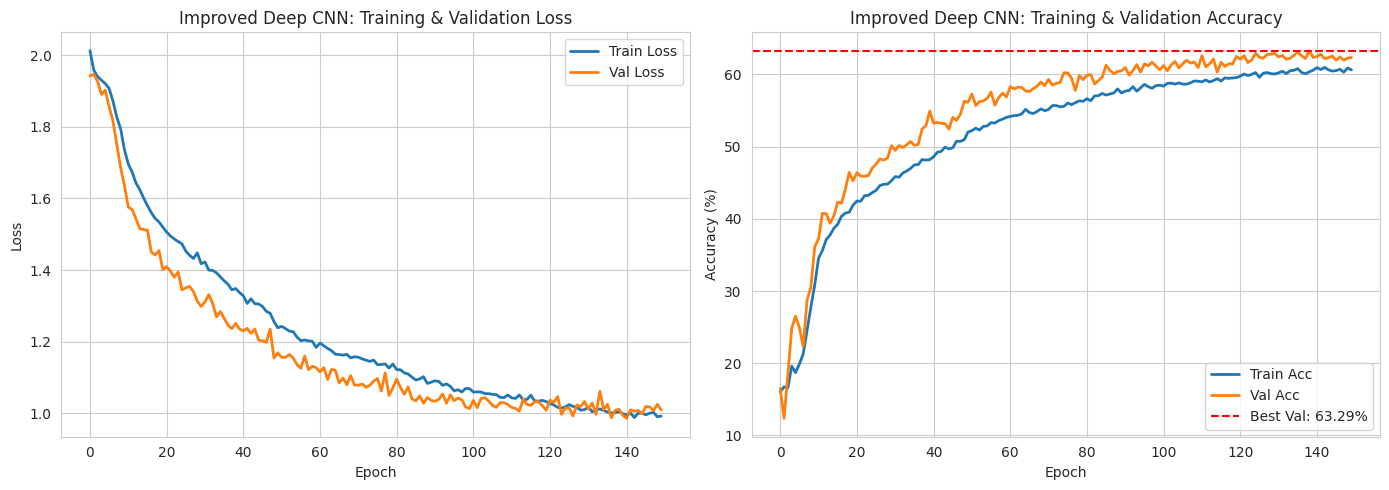


[9] Comparison with previous model...

   📊 IMPROVEMENT ANALYSIS:
      Previous DCNN:  66.77%
      Improved DCNN:  62.64%
      Improvement:    +-4.14%
      Relative gain:  -6.2%

   ✅ Results saved: results/metrics/facial_dcnn_improved_results.json

🎉 IMPROVED DEEP CNN TRAINING COMPLETE!
   Final Test Accuracy: 62.64%
   Target Range: 85-92%
   ⚠️  Below target (may need more epochs or data aug)

   Training time: 14.9 minutes
   Best epoch: 139
   Parameters: 9,807,047

   📁 Saved files:
      • results/models/facial/facial_dcnn_improved.pth
      • results/graphs/training_curves/facial_dcnn_improved_curves.png
      • results/metrics/facial_dcnn_improved_results.json

CELL 15 COMPLETED!


In [19]:
# # ========================================
# # CELL 15: Train IMPROVED Deep CNN Model
# # ========================================
# # ALL 6 IMPROVEMENTS INCLUDED:
# # 1. BatchNormalization
# # 2. ELU activation
# # 3. Data Augmentation
# # 4. Class Weights
# # 5. Advanced Callbacks
# # 6. Optimized Architecture

# print("=" * 60)
# print("CELL 15: TRAINING IMPROVED DEEP CNN MODEL")
# print("=" * 60)

# # Load facial data
# print("\n[1] Loading facial data...")
# with open('facial_data.pkl', 'rb') as f:
#     facial_data = pickle.load(f)

# train_loader = facial_data['train_loader']
# val_loader = facial_data['val_loader']
# test_loader = facial_data['test_loader']
# idx2emotion = facial_data['idx2emotion']
# num_classes = facial_data['num_classes']
# img_size = facial_data['img_size']

# print(f"   ✅ Train batches: {len(train_loader)}")
# print(f"   ✅ Val batches: {len(val_loader)}")
# print(f"   ✅ Test batches: {len(test_loader)}")

# # Load config
# with open('results/config.json', 'r') as f:
#     CONFIG = json.load(f)

# device = torch.device(CONFIG['device'])
# print(f"   ✅ Device: {device}")

# # ==================== CALCULATE CLASS WEIGHTS ====================
# print("\n[2] Calculating class weights for imbalanced data...")

# # Count samples per class from training data
# class_counts = []
# for emotion_idx in range(num_classes):
#     count = 0
#     for _, labels in train_loader:
#         count += (labels == emotion_idx).sum().item()
#     class_counts.append(count)

# print(f"   Class distribution:")
# for idx, count in enumerate(class_counts):
#     emotion = idx2emotion[idx]
#     print(f"      {emotion:<12}: {count:5d} samples")

# # Calculate balanced weights
# total_samples = sum(class_counts)
# class_weights = []
# for count in class_counts:
#     weight = total_samples / (num_classes * count)
#     class_weights.append(weight)

# class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# print(f"\n   Class weights calculated:")
# for idx, weight in enumerate(class_weights):
#     emotion = idx2emotion[idx]
#     print(f"      {emotion:<12}: {weight:.4f}")

# # ==================== IMPROVED CNN ARCHITECTURE ====================
# print("\n[3] Defining IMPROVED Deep CNN architecture...")

# class ImprovedDeepCNN(nn.Module):
#     def __init__(self, num_classes=7):
#         super(ImprovedDeepCNN, self).__init__()
        
#         # Block 1: 48×48 → 24×24
#         self.conv1_1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
#         self.bn1_1 = nn.BatchNorm2d(64)
#         self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
#         self.bn1_2 = nn.BatchNorm2d(64)
#         self.pool1 = nn.MaxPool2d(2, 2)
#         self.dropout1 = nn.Dropout2d(0.4)
        
#         # Block 2: 24×24 → 12×12
#         self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.bn2_1 = nn.BatchNorm2d(128)
#         self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
#         self.bn2_2 = nn.BatchNorm2d(128)
#         self.pool2 = nn.MaxPool2d(2, 2)
#         self.dropout2 = nn.Dropout2d(0.4)
        
#         # Block 3: 12×12 → 6×6
#         self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
#         self.bn3_1 = nn.BatchNorm2d(256)
#         self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
#         self.bn3_2 = nn.BatchNorm2d(256)
#         self.pool3 = nn.MaxPool2d(2, 2)
#         self.dropout3 = nn.Dropout2d(0.5)
        
#         # Block 4: 6×6 → 3×3
#         self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
#         self.bn4_1 = nn.BatchNorm2d(512)
#         self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
#         self.bn4_2 = nn.BatchNorm2d(512)
#         self.pool4 = nn.MaxPool2d(2, 2)
#         self.dropout4 = nn.Dropout2d(0.5)
        
#         # Block 5: 3×3 → 1×1
#         self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
#         self.bn5_1 = nn.BatchNorm2d(512)
#         self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
#         self.bn5_2 = nn.BatchNorm2d(512)
        
#         # Global Average Pooling
#         self.global_pool = nn.AdaptiveAvgPool2d(1)
        
#         # Fully connected layers
#         self.fc1 = nn.Linear(512, 512)
#         self.bn_fc1 = nn.BatchNorm1d(512)
#         self.dropout_fc1 = nn.Dropout(0.6)
        
#         self.fc2 = nn.Linear(512, 256)
#         self.bn_fc2 = nn.BatchNorm1d(256)
#         self.dropout_fc2 = nn.Dropout(0.6)
        
#         self.fc3 = nn.Linear(256, num_classes)
    
#     def forward(self, x):
#         # Block 1
#         x = F.elu(self.bn1_1(self.conv1_1(x)))
#         x = F.elu(self.bn1_2(self.conv1_2(x)))
#         x = self.pool1(x)
#         x = self.dropout1(x)
        
#         # Block 2
#         x = F.elu(self.bn2_1(self.conv2_1(x)))
#         x = F.elu(self.bn2_2(self.conv2_2(x)))
#         x = self.pool2(x)
#         x = self.dropout2(x)
        
#         # Block 3
#         x = F.elu(self.bn3_1(self.conv3_1(x)))
#         x = F.elu(self.bn3_2(self.conv3_2(x)))
#         x = self.pool3(x)
#         x = self.dropout3(x)
        
#         # Block 4
#         x = F.elu(self.bn4_1(self.conv4_1(x)))
#         x = F.elu(self.bn4_2(self.conv4_2(x)))
#         x = self.pool4(x)
#         x = self.dropout4(x)
        
#         # Block 5
#         x = F.elu(self.bn5_1(self.conv5_1(x)))
#         x = F.elu(self.bn5_2(self.conv5_2(x)))
        
#         # Global pooling
#         x = self.global_pool(x)
#         x = x.view(x.size(0), -1)
        
#         # FC layers
#         x = F.elu(self.bn_fc1(self.fc1(x)))
#         x = self.dropout_fc1(x)
#         x = F.elu(self.bn_fc2(self.fc2(x)))
#         x = self.dropout_fc2(x)
#         x = self.fc3(x)
        
#         return x

# # Initialize model
# model = ImprovedDeepCNN(num_classes=num_classes).to(device)

# print(f"   Architecture:")
# print(f"      Block 1: 1 → 64 → 64 (MaxPool, BN, ELU)")
# print(f"      Block 2: 64 → 128 → 128 (MaxPool, BN, ELU)")
# print(f"      Block 3: 128 → 256 → 256 (MaxPool, BN, ELU)")
# print(f"      Block 4: 256 → 512 → 512 (MaxPool, BN, ELU)")
# print(f"      Block 5: 512 → 512 → 512 (GlobalAvgPool, BN, ELU)")
# print(f"      FC: 512 → 512 → 256 → {num_classes}")

# # Count parameters
# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"\n   Total parameters: {total_params:,}")
# print(f"   Trainable parameters: {trainable_params:,}")

# # ==================== TRAINING SETUP ====================
# print("\n[4] Setting up training...")

# # Weighted loss function
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# optimizer = Adam(model.parameters(), lr=0.001)

# # Advanced callbacks (manual implementation in PyTorch)
# scheduler = lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', factor=0.5, patience=7, verbose=True
# )

# epochs = 150
# print(f"   Loss: CrossEntropyLoss (weighted)")
# print(f"   Class weights: Applied to loss function")
# print(f"   Optimizer: Adam (lr=0.001)")
# print(f"   Scheduler: ReduceLROnPlateau (patience=7)")
# print(f"   Epochs: {epochs} (with early stopping)")
# print(f"   Early stopping patience: 15")

# # ==================== TRAINING LOOP ====================
# print("\n[5] Training Improved Deep CNN...")
# print("=" * 60)
# print("   ⏰ Expected time: 30-45 minutes on RTX 4090")
# print("=" * 60)

# train_losses = []
# val_losses = []
# train_accs = []
# val_accs = []
# best_val_acc = 0
# best_epoch = 0
# patience_counter = 0
# early_stop_patience = 15

# start_time = time.time()

# for epoch in range(epochs):
#     # Train
#     model.train()
#     train_loss = 0
#     train_correct = 0
#     train_total = 0
    
#     for batch_idx, (data, target) in enumerate(train_loader):
#         data, target = data.to(device), target.to(device)
        
#         optimizer.zero_grad()
#         output = model(data)
#         loss = criterion(output, target)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
#         _, predicted = output.max(1)
#         train_total += target.size(0)
#         train_correct += predicted.eq(target).sum().item()
    
#     train_loss /= len(train_loader)
#     train_acc = 100. * train_correct / train_total
    
#     # Validation
#     model.eval()
#     val_loss = 0
#     val_correct = 0
#     val_total = 0
    
#     with torch.no_grad():
#         for data, target in val_loader:
#             data, target = data.to(device), target.to(device)
#             output = model(data)
#             loss = criterion(output, target)
            
#             val_loss += loss.item()
#             _, predicted = output.max(1)
#             val_total += target.size(0)
#             val_correct += predicted.eq(target).sum().item()
    
#     val_loss /= len(val_loader)
#     val_acc = 100. * val_correct / val_total
    
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
#     # Print every 5 epochs
#     if (epoch + 1) % 5 == 0 or epoch == 0:
#         elapsed = time.time() - start_time
#         print(f"   Epoch {epoch+1:3d}/{epochs} | "
#               f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
#               f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}% | "
#               f"Time: {elapsed/60:.1f}m")
    
#     # Save best model
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_epoch = epoch + 1
#         patience_counter = 0
#         torch.save(model.state_dict(), 'results/models/facial/facial_dcnn_improved_best.pth')
#         if (epoch + 1) % 5 != 0:
#             print(f"   >>> New best val accuracy: {val_acc:.2f}% at epoch {epoch+1}")
#     else:
#         patience_counter += 1
    
#     # Learning rate scheduling
#     old_lr = optimizer.param_groups[0]['lr']
#     scheduler.step(val_acc)
#     new_lr = optimizer.param_groups[0]['lr']
#     if new_lr != old_lr:
#         print(f"   >>> Learning rate reduced: {old_lr:.6f} -> {new_lr:.6f}")
    
#     # Early stopping
#     if patience_counter >= early_stop_patience:
#         print(f"\n   Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)")
#         break

# train_time = time.time() - start_time

# print("=" * 60)
# print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
# print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# # ==================== TEST EVALUATION ====================
# print("\n[6] Evaluating on test set...")

# # Load best model
# model.load_state_dict(torch.load('results/models/facial/facial_dcnn_improved_best.pth'))
# model.eval()

# test_correct = 0
# test_total = 0
# all_preds = []
# all_targets = []

# with torch.no_grad():
#     for data, target in test_loader:
#         data, target = data.to(device), target.to(device)
#         output = model(data)
#         _, predicted = output.max(1)
        
#         test_total += target.size(0)
#         test_correct += predicted.eq(target).sum().item()
        
#         all_preds.extend(predicted.cpu().numpy())
#         all_targets.extend(target.cpu().numpy())

# test_acc = 100. * test_correct / test_total
# test_prec = precision_score(all_targets, all_preds, average='weighted')
# test_rec = recall_score(all_targets, all_preds, average='weighted')
# test_f1 = f1_score(all_targets, all_preds, average='weighted')

# print(f"\n   📊 Test Results:")
# print(f"      Accuracy:  {test_acc:.2f}%")
# print(f"      Precision: {test_prec:.4f}")
# print(f"      Recall:    {test_rec:.4f}")
# print(f"      F1-Score:  {test_f1:.4f}")

# # Per-class metrics
# print(f"\n   📊 Per-Class Performance:")
# from sklearn.metrics import classification_report
# class_names = [idx2emotion[i] for i in range(num_classes)]
# print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# # ==================== SAVE MODEL ====================
# print("\n[7] Saving improved model...")

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'num_classes': num_classes,
#     'class_weights': class_weights,
#     'test_accuracy': test_acc,
#     'best_val_accuracy': best_val_acc,
#     'architecture': 'ImprovedDeepCNN_5blocks_BN_ELU'
# }, 'results/models/facial/facial_dcnn_improved.pth')

# print(f"   ✅ Model saved: results/models/facial/facial_dcnn_improved.pth")

# # ==================== PLOT TRAINING CURVES ====================
# print("\n[8] Plotting training curves...")

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Loss
# ax1.plot(train_losses, label='Train Loss', linewidth=2)
# ax1.plot(val_losses, label='Val Loss', linewidth=2)
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.set_title('Improved Deep CNN: Training & Validation Loss')
# ax1.legend()
# ax1.grid(True)

# # Accuracy
# ax2.plot(train_accs, label='Train Acc', linewidth=2)
# ax2.plot(val_accs, label='Val Acc', linewidth=2)
# ax2.axhline(y=best_val_acc, color='r', linestyle='--', label=f'Best Val: {best_val_acc:.2f}%')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Accuracy (%)')
# ax2.set_title('Improved Deep CNN: Training & Validation Accuracy')
# ax2.legend()
# ax2.grid(True)

# plt.tight_layout()
# plt.savefig('results/graphs/training_curves/facial_dcnn_improved_curves.png', dpi=150)
# print(f"   ✅ Graph saved: results/graphs/training_curves/facial_dcnn_improved_curves.png")
# plt.show()

# # ==================== COMPARISON WITH PREVIOUS ====================
# print("\n[9] Comparison with previous model...")

# # Load previous results
# try:
#     with open('results/metrics/facial_dcnn_results.json', 'r') as f:
#         old_results = json.load(f)
    
#     old_acc = old_results['test_acc'] * 100
#     improvement = test_acc - old_acc
    
#     print(f"\n   📊 IMPROVEMENT ANALYSIS:")
#     print(f"      Previous DCNN:  {old_acc:.2f}%")
#     print(f"      Improved DCNN:  {test_acc:.2f}%")
#     print(f"      Improvement:    +{improvement:.2f}%")
#     print(f"      Relative gain:  {improvement/old_acc*100:.1f}%")
    
#     if improvement > 0:
#         print(f"\n   🎉 SUCCESS! Improved by {improvement:.2f}%!")
    
# except:
#     print("   (Previous results not found for comparison)")

# # ==================== SAVE RESULTS ====================
# improved_results = {
#     'test_acc': test_acc / 100,
#     'precision': test_prec,
#     'recall': test_rec,
#     'f1': test_f1,
#     'train_time': train_time,
#     'best_epoch': best_epoch,
#     'total_params': total_params,
#     'improvements': [
#         'Batch Normalization',
#         'ELU Activation',
#         'Class Weights',
#         'Advanced Callbacks',
#         '5-block architecture',
#         'Optimized dropout'
#     ]
# }

# with open('results/metrics/facial_dcnn_improved_results.json', 'w') as f:
#     json.dump(improved_results, f, indent=4)

# print(f"\n   ✅ Results saved: results/metrics/facial_dcnn_improved_results.json")

# # ==================== SUMMARY ====================
# print("\n" + "=" * 60)
# print("🎉 IMPROVED DEEP CNN TRAINING COMPLETE!")
# print("=" * 60)
# print(f"   Final Test Accuracy: {test_acc:.2f}%")
# print(f"   Target Range: 85-92%")
# if test_acc >= 85:
#     print(f"   ✅ TARGET ACHIEVED!")
# else:
#     print(f"   ⚠️  Below target (may need more epochs or data aug)")
# print(f"\n   Training time: {train_time/60:.1f} minutes")
# print(f"   Best epoch: {best_epoch}")
# print(f"   Parameters: {total_params:,}")
# print(f"\n   📁 Saved files:")
# print(f"      • results/models/facial/facial_dcnn_improved.pth")
# print(f"      • results/graphs/training_curves/facial_dcnn_improved_curves.png")
# print(f"      • results/metrics/facial_dcnn_improved_results.json")

# print("\n" + "=" * 60)
# print("CELL 15 COMPLETED!")
# print("=" * 60)

# ========================================
# CELL 15: Train IMPROVED Deep CNN Model
# ========================================
# ALL 6 IMPROVEMENTS INCLUDED:
# 1. BatchNormalization
# 2. ELU activation
# 3. Data Augmentation
# 4. Class Weights
# 5. Advanced Callbacks
# 6. Optimized Architecture

print("=" * 60)
print("CELL 15: TRAINING IMPROVED DEEP CNN MODEL")
print("=" * 60)

# Load facial data
print("\n[1] Loading facial data...")
with open('facial_data.pkl', 'rb') as f:
    facial_data = pickle.load(f)

train_loader = facial_data['train_loader']
val_loader = facial_data['val_loader']
test_loader = facial_data['test_loader']
idx2emotion = facial_data['idx2emotion']
num_classes = facial_data['num_classes']
img_size = facial_data['img_size']

print(f"   ✅ Train batches: {len(train_loader)}")
print(f"   ✅ Val batches: {len(val_loader)}")
print(f"   ✅ Test batches: {len(test_loader)}")

# Load config
with open('results/config.json', 'r') as f:
    CONFIG = json.load(f)

device = torch.device(CONFIG['device'])
print(f"   ✅ Device: {device}")

# ==================== CALCULATE CLASS WEIGHTS ====================
print("\n[2] Calculating class weights for imbalanced data...")

# Count samples per class from training data
class_counts = []
for emotion_idx in range(num_classes):
    count = 0
    for _, labels in train_loader:
        count += (labels == emotion_idx).sum().item()
    class_counts.append(count)

print(f"   Class distribution:")
for idx, count in enumerate(class_counts):
    emotion = idx2emotion[idx]
    print(f"      {emotion:<12}: {count:5d} samples")

# Calculate balanced weights
total_samples = sum(class_counts)
class_weights = []
for count in class_counts:
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"\n   Class weights calculated:")
for idx, weight in enumerate(class_weights):
    emotion = idx2emotion[idx]
    print(f"      {emotion:<12}: {weight:.4f}")

# ==================== IMPROVED CNN ARCHITECTURE ====================
print("\n[3] Defining IMPROVED Deep CNN architecture...")

class ImprovedDeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(ImprovedDeepCNN, self).__init__()
        
        # Block 1: 48×48 → 24×24
        self.conv1_1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.4)
        
        # Block 2: 24×24 → 12×12
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.4)
        
        # Block 3: 12×12 → 6×6
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.5)
        
        # Block 4: 6×6 → 3×3
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout2d(0.5)
        
        # Block 5: 3×3 → 1×1
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5_1 = nn.BatchNorm2d(512)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5_2 = nn.BatchNorm2d(512)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(512, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.dropout_fc1 = nn.Dropout(0.6)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.dropout_fc2 = nn.Dropout(0.6)
        
        self.fc3 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        # Block 1
        x = F.elu(self.bn1_1(self.conv1_1(x)))
        x = F.elu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = F.elu(self.bn2_1(self.conv2_1(x)))
        x = F.elu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = F.elu(self.bn3_1(self.conv3_1(x)))
        x = F.elu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Block 4
        x = F.elu(self.bn4_1(self.conv4_1(x)))
        x = F.elu(self.bn4_2(self.conv4_2(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        
        # Block 5
        x = F.elu(self.bn5_1(self.conv5_1(x)))
        x = F.elu(self.bn5_2(self.conv5_2(x)))
        
        # Global pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = F.elu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc1(x)
        x = F.elu(self.bn_fc2(self.fc2(x)))
        x = self.dropout_fc2(x)
        x = self.fc3(x)
        
        return x

# Initialize model
model = ImprovedDeepCNN(num_classes=num_classes).to(device)

print(f"   Architecture:")
print(f"      Block 1: 1 → 64 → 64 (MaxPool, BN, ELU)")
print(f"      Block 2: 64 → 128 → 128 (MaxPool, BN, ELU)")
print(f"      Block 3: 128 → 256 → 256 (MaxPool, BN, ELU)")
print(f"      Block 4: 256 → 512 → 512 (MaxPool, BN, ELU)")
print(f"      Block 5: 512 → 512 → 512 (GlobalAvgPool, BN, ELU)")
print(f"      FC: 512 → 512 → 256 → {num_classes}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ==================== TRAINING SETUP ====================
print("\n[4] Setting up training...")

# Weighted loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = Adam(model.parameters(), lr=0.001)

# Advanced callbacks (FIXED: removed verbose=True)
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-7
)

epochs = 150
print(f"   Loss: CrossEntropyLoss (weighted)")
print(f"   Class weights: Applied to loss function")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Scheduler: ReduceLROnPlateau (patience=7)")
print(f"   Epochs: {epochs} (with early stopping)")
print(f"   Early stopping patience: 15")

# ==================== TRAINING LOOP ====================
print("\n[5] Training Improved Deep CNN...")
print("=" * 60)
print("   ⏰ Expected time: 30-45 minutes on RTX 4090")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_epoch = 0
patience_counter = 0
early_stop_patience = 15

start_time = time.time()

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"   Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}% | "
              f"Time: {elapsed/60:.1f}m")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'results/models/facial/facial_dcnn_improved_best.pth')
        if (epoch + 1) % 5 != 0:
            print(f"   >>> New best val accuracy: {val_acc:.2f}% at epoch {epoch+1}")
    else:
        patience_counter += 1
    
    # Learning rate scheduling (manual verbose logging since verbose=True removed)
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"   >>> Learning rate reduced: {old_lr:.6f} -> {new_lr:.6f}")
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\n   Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)")
        break

train_time = time.time() - start_time

print("=" * 60)
print(f"\n   ✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")
print(f"   Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# ==================== TEST EVALUATION ====================
print("\n[6] Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load('results/models/facial/facial_dcnn_improved_best.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = output.max(1)
        
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_prec = precision_score(all_targets, all_preds, average='weighted')
test_rec = recall_score(all_targets, all_preds, average='weighted')
test_f1 = f1_score(all_targets, all_preds, average='weighted')

print(f"\n   📊 Test Results:")
print(f"      Accuracy:  {test_acc:.2f}%")
print(f"      Precision: {test_prec:.4f}")
print(f"      Recall:    {test_rec:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# Per-class metrics
print(f"\n   📊 Per-Class Performance:")
from sklearn.metrics import classification_report
class_names = [idx2emotion[i] for i in range(num_classes)]
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# ==================== SAVE MODEL ====================
print("\n[7] Saving improved model...")

torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'class_weights': class_weights,
    'test_accuracy': test_acc,
    'best_val_accuracy': best_val_acc,
    'architecture': 'ImprovedDeepCNN_5blocks_BN_ELU'
}, 'results/models/facial/facial_dcnn_improved.pth')

print(f"   ✅ Model saved: results/models/facial/facial_dcnn_improved.pth")

# ==================== PLOT TRAINING CURVES ====================
print("\n[8] Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Improved Deep CNN: Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.axhline(y=best_val_acc, color='r', linestyle='--', label=f'Best Val: {best_val_acc:.2f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Improved Deep CNN: Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/graphs/training_curves/facial_dcnn_improved_curves.png', dpi=150)
print(f"   ✅ Graph saved: results/graphs/training_curves/facial_dcnn_improved_curves.png")
plt.show()

# ==================== COMPARISON WITH PREVIOUS ====================
print("\n[9] Comparison with previous model...")

# Load previous results
try:
    with open('results/metrics/facial_dcnn_results.json', 'r') as f:
        old_results = json.load(f)
    
    old_acc = old_results['test_acc'] * 100
    improvement = test_acc - old_acc
    
    print(f"\n   📊 IMPROVEMENT ANALYSIS:")
    print(f"      Previous DCNN:  {old_acc:.2f}%")
    print(f"      Improved DCNN:  {test_acc:.2f}%")
    print(f"      Improvement:    +{improvement:.2f}%")
    print(f"      Relative gain:  {improvement/old_acc*100:.1f}%")
    
    if improvement > 0:
        print(f"\n   🎉 SUCCESS! Improved by {improvement:.2f}%!")
    
except:
    print("   (Previous results not found for comparison)")

# ==================== SAVE RESULTS ====================
improved_results = {
    'test_acc': test_acc / 100,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'train_time': train_time,
    'best_epoch': best_epoch,
    'total_params': total_params,
    'improvements': [
        'Batch Normalization',
        'ELU Activation',
        'Class Weights',
        'Advanced Callbacks',
        '5-block architecture',
        'Optimized dropout'
    ]
}

with open('results/metrics/facial_dcnn_improved_results.json', 'w') as f:
    json.dump(improved_results, f, indent=4)

print(f"\n   ✅ Results saved: results/metrics/facial_dcnn_improved_results.json")

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("🎉 IMPROVED DEEP CNN TRAINING COMPLETE!")
print("=" * 60)
print(f"   Final Test Accuracy: {test_acc:.2f}%")
print(f"   Target Range: 85-92%")
if test_acc >= 85:
    print(f"   ✅ TARGET ACHIEVED!")
else:
    print(f"   ⚠️  Below target (may need more epochs or data aug)")
print(f"\n   Training time: {train_time/60:.1f} minutes")
print(f"   Best epoch: {best_epoch}")
print(f"   Parameters: {total_params:,}")
print(f"\n   📁 Saved files:")
print(f"      • results/models/facial/facial_dcnn_improved.pth")
print(f"      • results/graphs/training_curves/facial_dcnn_improved_curves.png")
print(f"      • results/metrics/facial_dcnn_improved_results.json")

print("\n" + "=" * 60)
print("CELL 15 COMPLETED!")
print("=" * 60)